$$
\begin{array}{c}
\textbf{Linear Regression - Spring 2026}\\\\
\textit{Center for Data Science, New York University} \\\\
\textit{April 3, 2026}\\\\\
\text{ Prepared by: Vivek Kumar Agarwal}\\\\
\textbf{Recitation 8: Linear Regression}
\end{array}
$$

![Linear Regression](../figures/LR_lab8_image1.png)

---

# Recitation: Shrinkage Methods
## LASSO, Ridge Regression & Elastic Net

---

## Today's Outline

1. **Motivation** — Why do we need shrinkage? The feature selection problem
2. **LASSO** — Penalized regression, the λ hyperparameter, sparsity
3. **The Geometry of Shrinkage** — Why LASSO zeros out and Ridge doesn't
4. **Bias-Variance Tradeoff** — Understanding λ through the lens of what we already know
5. **Standardization** — Why it matters before applying shrinkage methods
6. **LASSO in Code** — Car price prediction: tuning λ, coefficient paths
7. **Ridge Regression** — A different penalty, a different behavior
8. **Ridge in Code** — Comparing MSE curves and coefficient paths to LASSO
9. **When To Use Which Method** — A decision framework with the math
10. **Elastic Net** — Combining both penalties
11. **Key Takeaways**

---

*what we have learnt so far: OLS, MLR, Bias-Variance Tradeoff, Train/Test Splits, MSE*

## Motivation — The Feature Selection Problem

Suppose we have a dataset with one target variable $Y$ and many possible
predictor variables $X_1, X_2, \ldots, X_k$.

For **predictive purposes**, we want to include features that are informative
and exclude those that aren't. But how do we decide?

---

### The Naive Approaches (and Why They Fail)

**Option 1: Pick by hand**
> "Horsepower probably matters more than number of doors..."

This is ad-hoc and limited by the quality of our intuition.
Works for 3 features. Falls apart at 50.

**Option 2: Trial and error with train/test sets**
> "Let's just try every possible combination of features..."

The number of possible models explodes **combinatorially**:

| Features | Possible Models |
|----------|----------------|
| 10       | 1,024 |
| 20       | 1,048,576 |
| 50       | 1,125,899,906,842,624 |

In general, with $k$ features there are $2^k$ possible models. This is completely intractable for moderate $k$.

---

### The Key Insight

Including too many features → **overfitting** (high variance)

Excluding too many features → **losing information** (high bias)

We need a way to turn this into a problem with a **clear hyperparameter to tune**.

> This is exactly what shrinkage methods do.

---

## LASSO Regression
### Least Absolute Shrinkage and Selection Operator

Recall that standard OLS finds the **Best Linear Predictor** by solving:

$$\min_{b_0, b_1, \ldots, b_k} \mathbb{E}\left[\left(Y - \left(b_0 + \sum_{i=1}^{k} b_i X_i\right)\right)^2\right]$$

> **Notation note:** The $b$'s are placeholder variables we minimize over —
> think of them as "candidate values" we're testing. Once we solve the problem,
> the winning values become our estimates $\hat{\beta}_0, \hat{\beta}_1, \ldots, \hat{\beta}_k$.
> This is the same convention we used back in the BLP.

---

### The LASSO Modification

LASSO adds a **penalty term** to the OLS problem:

$$\min_{b_0, b_1, \ldots, b_k} \underbrace{\mathbb{E}\left[\left(Y - \left(b_0 + \sum_{i=1}^{k} b_i X_i\right)\right)^2\right]}_{\text{fit well (same as OLS)}} + \underbrace{\lambda\left(\sum_{i=1}^{k} |b_i|\right)}_{\text{stay small (new penalty)}}$$

We are now simultaneously trying to:
- **Fit well** — minimize prediction error (same as OLS)
- **Stay small** — keep the total absolute magnitude of all coefficients low

The hyperparameter $\lambda \geq 0$ controls the **trade-off** between these two goals.

---

### Understanding $\lambda$

| Value of $\lambda$ | Effect |
|-------------------|--------|
| $\lambda = 0$ | Identical to OLS — no penalty at all |
| $\lambda$ small | Mild shrinkage — coefficients pulled slightly toward 0 |
| $\lambda$ large | Strong shrinkage — many coefficients forced to exactly 0 |
| $\lambda \to \infty$ | All coefficients → 0 (intercept only model) |

$\lambda$ is a **hyperparameter** — we don't estimate it from the data.
We tune it using a **train/test split**, exactly like we tuned polynomial degree:

1. Loop over a grid of $\lambda$ values (e.g. 0, 1, 2, ... 50)
2. For each $\lambda$, fit LASSO on the **training set**
3. Evaluate **MSE on the test set**
4. Pick the $\lambda$ with the **lowest test MSE**

The U-shaped MSE curve we'll see in the code is literally this tradeoff:
- Too small → overfitting (high variance)
- Too large → over-penalized (high bias)
- Just right → optimal balance ✓

---

### The Equivalent Constrained Form

LASSO can also be written as a **constrained optimization problem**:

$$\min_{b_0, b_1, \ldots, b_k} \mathbb{E}\left[\left(Y - \left(b_0 + \sum_{i=1}^{k} b_i X_i\right)\right)^2\right] \quad \text{subject to} \quad \sum_{i=1}^{k} |b_i| \leq \kappa$$

> **Important:** $\kappa$ (kappa) is completely unrelated to $k$ (number of features).

Think of $\kappa$ as a **total budget** for coefficient magnitude. For example
if $\kappa = 5$ and we have 3 features, a valid solution might be:

$$|b_1| + |b_2| + |b_3| = 1.2 + 3.8 + 0.0 = 5.0 \leq \kappa$$

Notice $b_3$ got its entire budget cut to **zero** — that feature is effectively
removed from the model. This is LASSO's key property: **sparsity**.

**In practice:** Nobody sets $\kappa$ directly. For any $\lambda$ you choose
in the penalized form, there is exactly one implied $\kappa$ that gives the
identical solution. We always tune $\lambda$ — $\kappa$ is just a
conceptual tool to build intuition.

---
## The Geometry of Shrinkage
### Why Does LASSO Zero Out Coefficients?

To understand this intuitively, let's think geometrically.
We'll use a simple case with just **two coefficients** $b_1$ and $b_2$.

---

### The OLS Solution

Without any penalty, OLS finds the **unconstrained minimum** — the single
point in $(b_1, b_2)$ space that minimizes prediction error.

Think of the prediction error as a set of **concentric ellipses** centered
on the OLS solution $\hat{\beta}^{OLS}$ — the further you move away from it,
the worse your fit gets.

---

### The LASSO Constraint Region

Recall the constrained form of LASSO:

$$\sum_{i=1}^{k} |b_i| \leq \kappa$$

In two dimensions this means:

$$|b_1| + |b_2| \leq \kappa$$

This constraint defines all the points $(b_1, b_2)$ that are "allowed."
Plotting this region in $(b_1, b_2)$ space gives us a **diamond** ◇

The constrained LASSO solution is found where the **ellipses of prediction
error first touch the diamond** as we expand outward from the OLS solution.

---

### Why LASSO Produces Zeros

- The corners of the diamond sit exactly **on the axes**
- i.e. at points like $(b_1, 0)$ or $(0, b_2)$
- The expanding ellipses are **very likely to hit a corner first**
- At a corner, one coefficient is exactly **zero**
- → LASSO naturally produces **sparse** solutions

> Later, when we introduce Ridge Regression, we'll see how a
> different constraint shape leads to very different behavior.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


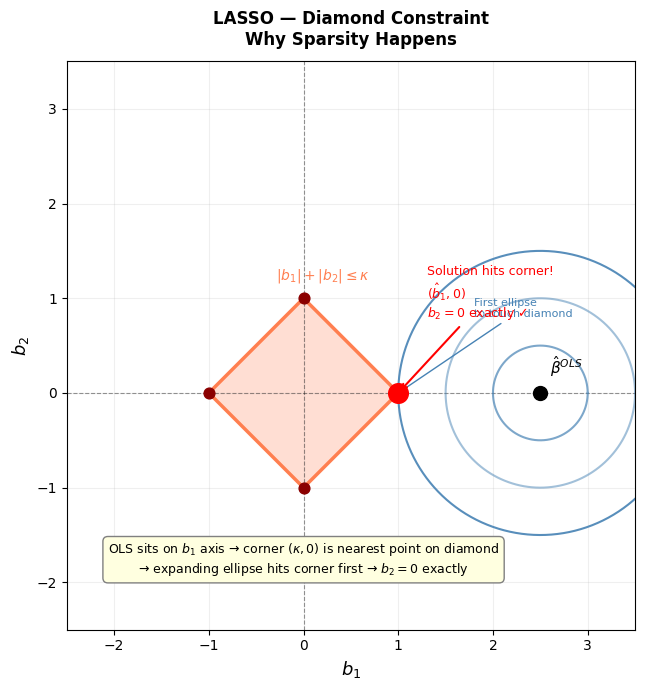

In [42]:


fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(-2.5, 3.5)
ax.set_ylim(-2.5, 3.5)
ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('$b_1$', fontsize=13)
ax.set_ylabel('$b_2$', fontsize=13)
ax.set_title('LASSO — Diamond Constraint\nWhy Sparsity Happens',
             fontsize=12, fontweight='bold', pad=12)

# OLS solution — placed directly on b1 axis
# So nearest point on diamond is provably corner (1, 0)
ols = np.array([2.5, 0.0])
ax.scatter(*ols, color='black', s=100, zorder=5)
ax.annotate('$\\hat{\\beta}^{OLS}$', ols,
            xytext=(ols[0]+0.1, ols[1]+0.2), fontsize=11)

# Circular expanding ellipses centered on OLS
# Radii: 0.5, 1.0, 1.5 (just touching diamond at r=1.5)
theta = np.linspace(0, 2*np.pi, 300)
for r, alpha, ls in zip([0.5, 1.0, 1.5],
                         [0.7, 0.5, 0.9],
                         ['-', '-', '-']):
    ax.plot(ols[0] + r*np.cos(theta),
            ols[1] + r*np.sin(theta),
            color='steelblue', alpha=alpha, lw=1.5, linestyle=ls)

# Label the touching ellipse
ax.annotate('First ellipse\nto touch diamond',
            xy=(1.0, 0.0),
            xytext=(1.8, 0.8),
            fontsize=8, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))

# Diamond constraint region
kappa = 1.0
diamond_x = [kappa, 0, -kappa, 0, kappa]
diamond_y = [0, kappa, 0, -kappa, 0]
ax.fill(diamond_x, diamond_y, color='coral', alpha=0.25)
ax.plot(diamond_x, diamond_y, color='coral', lw=2.5)
ax.text(0.2, kappa+0.2, '$|b_1| + |b_2| \\leq \\kappa$',
        ha='center', fontsize=10, color='coral')

# All four corners labeled
corners = [(kappa,0), (0,kappa), (-kappa,0), (0,-kappa)]
for cx, cy in corners:
    ax.scatter(cx, cy, color='darkred', s=60, zorder=6)

# Solution point — corner (1, 0)
sol = np.array([kappa, 0.0])
ax.scatter(*sol, color='red', s=200, zorder=7)
ax.annotate('Solution hits corner!\n'
            '$(\\hat{b}_1, 0)$\n'
            '$b_2 = 0$ exactly ✓',
            xy=sol,
            xytext=(sol[0]+0.3, sol[1]+0.8),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.text(0, -1.9,
        'OLS sits on $b_1$ axis → corner $(\\kappa, 0)$ is nearest point on diamond\n'
        '→ expanding ellipse hits corner first → $b_2 = 0$ exactly',
        ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray'))

ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## The Bias-Variance Tradeoff Through $\lambda$

We already know about the bias-variance tradeoff from polynomial regression:
- Too simple a model → **high bias** (underfitting)
- Too complex a model → **high variance** (overfitting)

LASSO's hyperparameter $\lambda$ governs **exactly the same tradeoff**:

---

### $\lambda$ as a Complexity Control

| $\lambda$ | Model Complexity | Bias | Variance |
|-----------|-----------------|------|----------|
| $\lambda = 0$ | Same as OLS — all features included | Low | High (overfitting) |
| $\lambda$ increasing | Coefficients shrink — fewer effective features | Increasing | Decreasing |
| $\lambda$ optimal | Best bias-variance balance | Just right | Just right |
| $\lambda \to \infty$ | All coefficients → 0 — intercept only | High (underfitting) | Very Low |

Just like increasing polynomial degree increases complexity,
**decreasing $\lambda$ increases complexity** in LASSO.

---

### Why Does Shrinkage Reduce Variance?

Recall from MLR that **imperfect collinearity** inflates variance —
when features are correlated, OLS coefficients become very sensitive
to the particular sample drawn.

LASSO directly addresses this:
- By penalizing large coefficients, it prevents the model from
  **overreacting** to peculiarities of a particular sample
- Coefficients that are "wildly large" due to collinearity
  get pulled back toward zero
- The result is estimates that are **more stable across different samples**
  at the cost of some bias

> This is the fundamental tradeoff shrinkage methods make:
> **accept a little bias in exchange for a lot less variance**

---

### The U-Shaped MSE Curve

This tradeoff plays out visually as the U-shaped test MSE curve we'll
see in the code:

$$\text{Test MSE} = \underbrace{\text{Bias}^2}_{\text{increases with } \lambda} + \underbrace{\text{Variance}}_{\text{decreases with } \lambda} + \text{Irreducible Error}$$

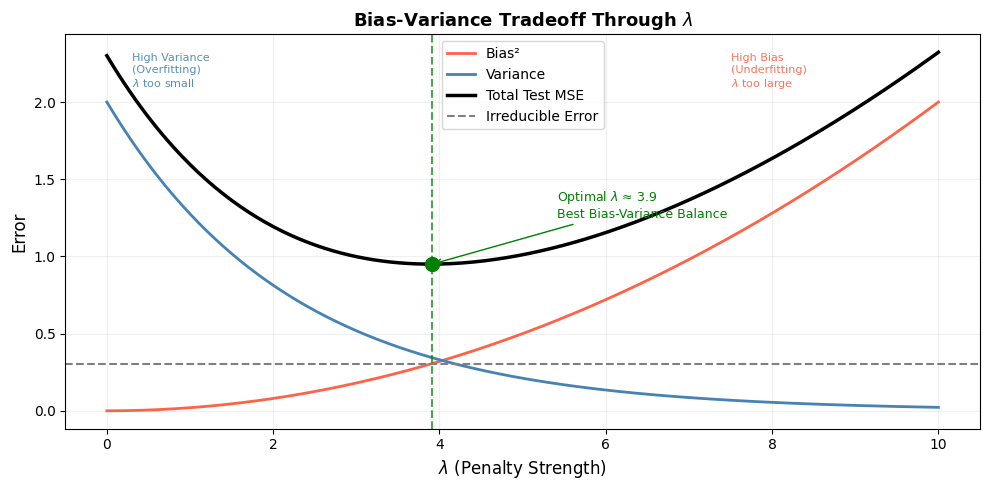

In [43]:


fig, ax = plt.subplots(figsize=(10, 5))

lambdas = np.linspace(0, 10, 300)

# Stylized bias^2, variance, and total MSE curves
bias2    = 0.5 * (lambdas / 5) ** 2
variance = 2.0 * np.exp(-0.45 * lambdas)
irreducible = 0.3
total_mse = bias2 + variance + irreducible

optimal_idx = np.argmin(total_mse)
optimal_lambda = lambdas[optimal_idx]

ax.plot(lambdas, bias2,    color='tomato',      lw=2, label='Bias²')
ax.plot(lambdas, variance, color='steelblue',   lw=2, label='Variance')
ax.plot(lambdas, total_mse,color='black',       lw=2.5, label='Total Test MSE')
ax.axhline(irreducible, color='gray', lw=1.5,
           linestyle='--', label='Irreducible Error')

# Mark optimal lambda
ax.axvline(optimal_lambda, color='green', lw=1.5,
           linestyle='--', alpha=0.7)
ax.scatter([optimal_lambda], [total_mse[optimal_idx]],
           color='green', s=100, zorder=5)
ax.annotate(f'Optimal $\\lambda$ ≈ {optimal_lambda:.1f}\nBest Bias-Variance Balance',
            xy=(optimal_lambda, total_mse[optimal_idx]),
            xytext=(optimal_lambda+1.5, total_mse[optimal_idx]+0.3),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

# Annotations for regions
ax.text(0.3, 2.1, 'High Variance\n(Overfitting)\n$\\lambda$ too small',
        fontsize=8, color='steelblue', alpha=0.9)
ax.text(7.5, 2.1, 'High Bias\n(Underfitting)\n$\\lambda$ too large',
        fontsize=8, color='tomato', alpha=0.9)

ax.set_xlabel('$\\lambda$ (Penalty Strength)', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Bias-Variance Tradeoff Through $\\lambda$', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Key Takeaway

$\lambda$ in LASSO plays the **exact same role** as polynomial degree did
before — it controls the complexity of the model and governs the
bias-variance tradeoff. We tune it the same way too: by finding the
value that minimizes **test set MSE**.

| Polynomial Regression | LASSO |
|----------------------|-------|
| Degree = 0 → underfit | $\lambda \to \infty$ → underfit |
| Degree too high → overfit | $\lambda = 0$ → overfit (= OLS) |
| Tune degree via test MSE | Tune $\lambda$ via test MSE |

---
## Standardization
### Why It Matters Before Applying Shrinkage Methods

LASSO penalizes the **magnitude** of coefficients. But coefficient magnitude
is directly affected by the **scale** of the underlying feature.

---

### The Problem With Different Scales

Consider two features in our car price dataset:

| Feature | Typical Range | Example Coefficient |
|---------|--------------|-------------------|
| Horsepower | 50 — 300 | Small (each unit = 1 HP) |
| Number of Doors | 2 — 4 | Large (each unit = 1 door) |

A one-unit change means something very different for each feature.
LASSO would unfairly penalize the horsepower coefficient more heavily
simply because its scale produces larger numbers — **not** because
it is less informative.

> Without standardization, LASSO is not comparing features on a
> **level playing field** — it's penalizing scale, not informativeness.

---

### The Solution — Standardization

For each non-indicator feature $X_i$, we replace it with its
**standardized version** $X_i^S$:

$$X_i^S = \frac{X_i - \bar{X}_i}{\hat{\sigma}_i}$$

Where:
- $\bar{X}_i$ = sample mean of feature $i$
- $\hat{\sigma}_i$ = sample standard deviation of feature $i$

This forces every feature to have:
- **Mean = 0**
- **Standard Deviation = 1**

Now a one-unit change in any feature means the same thing:
**one standard deviation** — a fair, comparable unit across all features.

---

### What About Indicator Variables?

Indicator (dummy) variables take values of 0 or 1 only —
standardizing them distorts their interpretation.

> **Rule of thumb:** Standardize continuous features only.
> Leave indicator variables as they are.

---

### Important — Standardize Using Training Data Only

When doing a train/test split, always fit the standardizer
**on the training set only**, then apply it to both:
```python
# Fit scaler on training data only
scaler = StandardScaler()
scaler.fit(X_train)

# Apply to both — using training mean and std
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

> If you fit the scaler on the full dataset before splitting,
> you are **leaking** test set information into training —
> the same mistake as fitting a model on the full data before splitting.

---
## Standardization vs Normalization
### A Quick Clarification

Two common scaling methods often get confused:

---

**Standardization (Z-score scaling)** — *what we use*
$$X^S = \frac{X - \bar{X}}{\hat{\sigma}}$$
- Forces **mean = 0, standard deviation = 1**
- No hard limits on output range (typically -3 to +3)
- Robust to outliers — they get scaled but not compressed
- The right choice for LASSO, Ridge, and Elastic Net

**Normalization (Min-Max scaling)** — *what we don't use here*
$$X^N = \frac{X - X_{min}}{X_{max} - X_{min}}$$
- Forces all values into the range **[0, 1]**
- Very sensitive to outliers — one extreme value
  compresses everything else into a tiny range
- More common in neural networks and distance-based methods

---

### Key Intuition

| | Standardization | Normalization |
|---|---|---|
| **Question it asks** | How many std devs from the mean? | What fraction from min to max? |
| **Output range** | No hard limit (~-3 to +3) | Strictly [0, 1] |
| **Outlier sensitivity** | Robust | Sensitive |
| **Use for LASSO/Ridge?** | ✓ Yes | ✗ No |
| **Use for Neural Nets?** | Sometimes | ✓ Common |

> For shrinkage methods we always prefer **standardization** because
> we care about relative informativeness across features —
> not compressing everything into a fixed range.

In [44]:


# ── Simulate Car Price Dataset ──────────────────────────────────────────────
# We simulate a dataset with 68 features to mirror the slides
# Features are a mix of continuous and indicator variables

np.random.seed(42)
n = 300  # number of cars

# Continuous features (these we will standardize)
horsepower   = np.random.normal(150, 50, n).clip(50, 300)
highwaympg   = np.random.normal(30, 8, n).clip(10, 55)
citympg      = 0.85 * highwaympg + np.random.normal(0, 2, n)  # correlated with highway
wheelbase    = np.random.normal(100, 12, n).clip(70, 130)
peakrpm      = np.random.normal(5000, 800, n).clip(3000, 7000)
enginesize   = np.random.normal(130, 40, n).clip(60, 300)
curbweight   = np.random.normal(2500, 400, n).clip(1500, 4000)
boreratio    = np.random.normal(3.3, 0.4, n).clip(2.5, 4.5)
stroke       = np.random.normal(3.2, 0.4, n).clip(2.0, 4.5)
compressionratio = np.random.normal(9, 3, n).clip(4, 20)

# Indicator features (do NOT standardize these)
is_turbo     = np.random.binomial(1, 0.3, n)
is_diesel    = np.random.binomial(1, 0.2, n)
is_awd       = np.random.binomial(1, 0.15, n)
is_luxury    = np.random.binomial(1, 0.25, n)
is_sports    = np.random.binomial(1, 0.2, n)

# Add 53 noise features (uninformative) to reach ~68 total features
noise_features = np.random.normal(0, 1, (n, 53))
noise_cols = [f'noise_{i}' for i in range(53)]

# True price model — only a few features actually matter
price = (
    8000
    + 60   * horsepower
    + 50   * peakrpm / 100
    - 30   * highwaympg
    + 20   * wheelbase
    + 40   * enginesize
    + 3000 * is_turbo
    + 2000 * is_luxury
    + 4000 * is_sports
    - 1500 * is_diesel
    + np.random.normal(0, 2000, n)   # noise
)

# ── Assemble DataFrame ───────────────────────────────────────────────────────
continuous_cols = ['horsepower', 'highwaympg', 'citympg', 'wheelbase',
                   'peakrpm', 'enginesize', 'curbweight', 'boreratio',
                   'stroke', 'compressionratio']

indicator_cols  = ['is_turbo', 'is_diesel', 'is_awd', 'is_luxury', 'is_sports']

df = pd.DataFrame({
    'horsepower'       : horsepower,
    'highwaympg'       : highwaympg,
    'citympg'          : citympg,
    'wheelbase'        : wheelbase,
    'peakrpm'          : peakrpm,
    'enginesize'       : enginesize,
    'curbweight'       : curbweight,
    'boreratio'        : boreratio,
    'stroke'           : stroke,
    'compressionratio' : compressionratio,
    'is_turbo'         : is_turbo,
    'is_diesel'        : is_diesel,
    'is_awd'           : is_awd,
    'is_luxury'        : is_luxury,
    'is_sports'        : is_sports,
    'price'            : price
})

# Add noise features
noise_df = pd.DataFrame(noise_features, columns=noise_cols)
df = pd.concat([df, noise_df], axis=1)

print(f"Dataset shape: {df.shape}")
print(f"Total features: {df.shape[1] - 1}")
print(f"\nFirst 5 rows:")
df[['horsepower','highwaympg','citympg','wheelbase','peakrpm','price']].head()

Dataset shape: (300, 69)
Total features: 68

First 5 rows:


,horsepower,highwaympg,citympg,wheelbase,peakrpm,price
0,174.835708,23.368040,21.376811,104.424080,5100.179602,35982.329262
1,143.086785,25.518552,19.846438,95.279934,4656.475567,25786.344208
2,182.384427,35.978349,32.320808,100.344938,5097.838002,27673.595793
3,226.151493,34.882962,32.361794,115.341422,5434.638423,35472.617602
4,138.292331,29.832787,26.184739,102.293189,5039.088056,26594.691149


In [45]:
# ── Train/Test Split ─────────────────────────────────────────────────────────
X = df.drop(columns='price')
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape[0]} observations")
print(f"Test set size     : {X_test.shape[0]} observations")

# ── Standardize Continuous Features Only ────────────────────────────────────
# IMPORTANT: fit scaler on training data only, then apply to both sets

scaler = StandardScaler()

# Fit on training set only
scaler.fit(X_train[continuous_cols])

# Apply to both — using training mean and std
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_cols] = scaler.transform(X_train[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print(f"\nAfter standardization — Training set continuous features:")
print(f"Mean  (should be ≈ 0): {X_train_scaled[continuous_cols].mean().round(3).values}")
print(f"Std   (should be ≈ 1): {X_train_scaled[continuous_cols].std().round(3).values}")

print(f"\nAfter standardization — Test set continuous features:")
print(f"Mean  (close to 0, not exact): {X_test_scaled[continuous_cols].mean().round(3).values}")
print(f"Std   (close to 1, not exact): {X_test_scaled[continuous_cols].std().round(3).values}")

print(f"\nIndicator features left unchanged ")
print(f"Scaler fitted on training data only ")

Training set size : 240 observations
Test set size     : 60 observations

After standardization — Training set continuous features:
Mean  (should be ≈ 0): [-0. -0.  0. -0.  0.  0. -0. -0.  0. -0.]
Std   (should be ≈ 1): [1.002 1.002 1.002 1.002 1.002 1.002 1.002 1.002 1.002 1.002]

After standardization — Test set continuous features:
Mean  (close to 0, not exact): [ 0.142 -0.36  -0.407 -0.191  0.429  0.133  0.094  0.084  0.002 -0.131]
Std   (close to 1, not exact): [0.826 0.92  0.978 0.942 0.954 1.069 1.062 1.072 0.987 0.986]

Indicator features left unchanged 
Scaler fitted on training data only 


In [46]:
# ── Loop Over λ Values, Fit LASSO, Record Test MSE ──────────────────────────
# This is the core pattern you will use in Assignment 4
# For each λ: fit LASSO on training set → evaluate MSE on test set

lambdas = list(range(0, 201))  

lasso_mse    = []   # store test MSE for each λ
lasso_models = []   # store fitted model for each λ (for coefficient paths later)

for lam in lambdas:

    # ── Step 1: Fit LASSO on training set ───────────────────────────────────
    # alpha in sklearn = λ in our notation
    # max_iter increased to ensure convergence
    lasso = Lasso(alpha=max(lam, 1e-6),  # avoid exact 0 (= OLS, not LASSO)
                  max_iter=10000,
                  random_state=42)

    lasso.fit(X_train_scaled, y_train)

    # ── Step 2: Predict on test set ─────────────────────────────────────────
    y_pred = lasso.predict(X_test_scaled)

    # ── Step 3: Record test MSE ─────────────────────────────────────────────
    mse = mean_squared_error(y_test, y_pred)
    lasso_mse.append(mse)
    lasso_models.append(lasso)

# ── Find Optimal λ ───────────────────────────────────────────────────────────
optimal_idx    = np.argmin(lasso_mse)
optimal_lambda = lambdas[optimal_idx]
optimal_mse    = lasso_mse[optimal_idx]

print("=" * 55)
print(f"  LASSO Results")
print("=" * 55)
print(f"  λ = 0  (OLS)     Test MSE : {lasso_mse[0]:,.0f}")
print(f"  Optimal λ        : {optimal_lambda}")
print(f"  Optimal Test MSE : {optimal_mse:,.0f}")
print(f"  λ = 50           Test MSE : {lasso_mse[-1]:,.0f}")
print("=" * 55)

# ── How Many Features Survived at Optimal λ? ────────────────────────────────
optimal_model    = lasso_models[optimal_idx]
n_nonzero        = np.sum(optimal_model.coef_ != 0)
n_zero           = np.sum(optimal_model.coef_ == 0)

print(f"\n  Total features         : {X_train_scaled.shape[1]}")
print(f"  Features kept (≠ 0)   : {n_nonzero}")
print(f"  Features kicked out   : {n_zero}")
print(f"\n  LASSO reduced {X_train_scaled.shape[1]} features")
print(f"  down to {n_nonzero} at optimal λ = {optimal_lambda} ")

  LASSO Results
  λ = 0  (OLS)     Test MSE : 4,920,827
  Optimal λ        : 75
  Optimal Test MSE : 3,654,163
  λ = 50           Test MSE : 4,824,537

  Total features         : 68
  Features kept (≠ 0)   : 36
  Features kicked out   : 32

  LASSO reduced 68 features
  down to 36 at optimal λ = 75 


✓  Full U-shape visible — optimal λ = 75
   Search range: 0 to 200


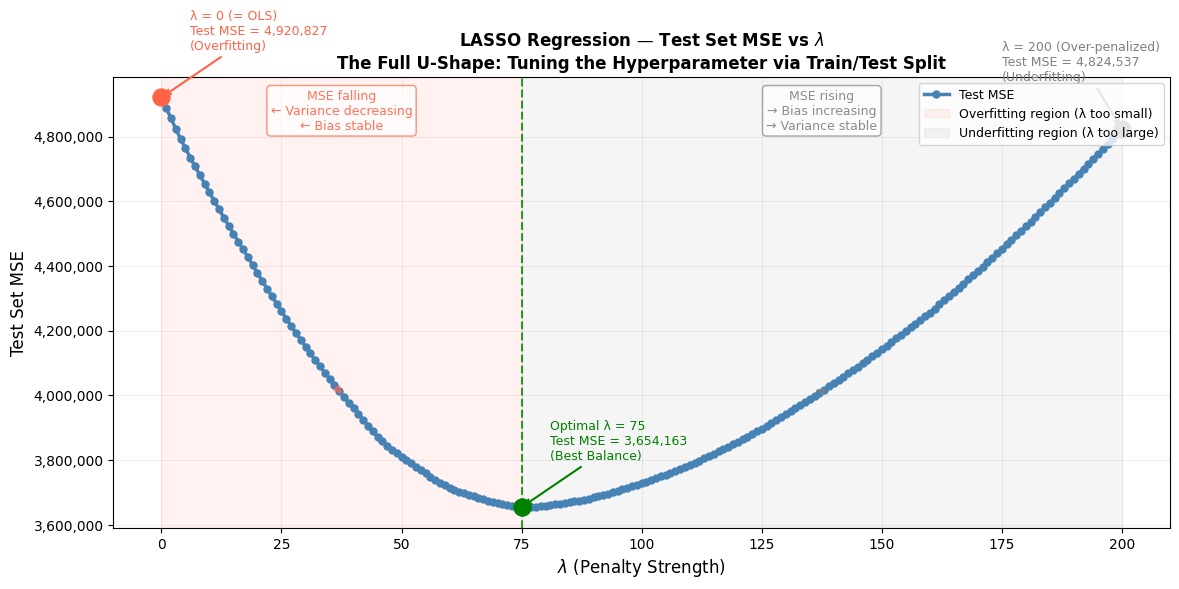


Reading the U-shaped curve:
  λ = 0          → OLS, no penalty    → MSE = 4,920,827  (overfitting)
  λ = 75           → optimal λ       → MSE = 3,654,163  (best balance) 
  λ = 200          → over-penalized  → MSE = 4,824,537  (underfitting)

  The lowest point of the curve is always our best λ.
  Too far left = overfitting. Too far right = underfitting.


In [47]:
# ── Plot LASSO Test MSE vs λ ─────────────────────────────────────────────────

# Check if we are seeing the full U-shape
if optimal_lambda >= max(lambdas) * 0.8:
    print(" Warning: optimal λ still near end of range — consider extending further.")
else:
    print(f"✓  Full U-shape visible — optimal λ = {optimal_lambda}")
    print(f"   Search range: 0 to {max(lambdas)}")

fig, ax = plt.subplots(figsize=(12, 6))

# ── Main MSE curve ───────────────────────────────────────────────────────────
ax.plot(lambdas, lasso_mse,
        color='steelblue', lw=2.5, marker='o',
        markersize=5, label='Test MSE')

# ── Shade overfitting and underfitting regions ───────────────────────────────
ax.axvspan(0, optimal_lambda,
           alpha=0.08, color='tomato',
           label='Overfitting region (λ too small)')
ax.axvspan(optimal_lambda, max(lambdas),
           alpha=0.08, color='gray',
           label='Underfitting region (λ too large)')

# ── Mark λ = 0 (OLS baseline) ───────────────────────────────────────────────
ax.scatter([0], [lasso_mse[0]],
           color='tomato', s=150, zorder=5)
ax.annotate(f'λ = 0 (= OLS)\nTest MSE = {lasso_mse[0]:,.0f}\n(Overfitting)',
            xy=(0, lasso_mse[0]),
            xytext=(6, lasso_mse[0] + lasso_mse[0]*0.03),
            fontsize=9, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))

# ── Mark optimal λ (bottom of U) ────────────────────────────────────────────
ax.axvline(optimal_lambda, color='green',
           lw=1.5, linestyle='--', alpha=0.8)
ax.scatter([optimal_lambda], [optimal_mse],
           color='green', s=150, zorder=5)
ax.annotate(f'Optimal λ = {optimal_lambda}\n'
            f'Test MSE = {optimal_mse:,.0f}\n'
            f'(Best Balance)',
            xy=(optimal_lambda, optimal_mse),
            xytext=(optimal_lambda + 6, optimal_mse + lasso_mse[0]*0.03),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

# ── Mark right end (over-penalized) ─────────────────────────────────────────
ax.scatter([max(lambdas)], [lasso_mse[-1]],
           color='gray', s=150, zorder=5)
ax.annotate(f'λ = {max(lambdas)} (Over-penalized)\n'
            f'Test MSE = {lasso_mse[-1]:,.0f}\n'
            f'(Underfitting)',
            xy=(max(lambdas), lasso_mse[-1]),
            xytext=(max(lambdas) - 25, lasso_mse[-1] + lasso_mse[0]*0.03),
            fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# ── Safe directional arrows ──────────────────────────────────────────────────
# Left side — MSE falling — pick safe indices within left region
left_region  = [i for i in range(len(lambdas)) if lambdas[i] < optimal_lambda]
right_region = [i for i in range(len(lambdas)) if lambdas[i] > optimal_lambda]

if len(left_region) >= 4:
    mid_left = left_region[len(left_region) // 2]
    ax.annotate('',
                xy=(lambdas[mid_left+1], lasso_mse[mid_left+1]),
                xytext=(lambdas[mid_left-1], lasso_mse[mid_left-1]),
                arrowprops=dict(arrowstyle='->', color='tomato',
                                lw=2, alpha=0.6))

if len(right_region) >= 4:
    mid_right = right_region[len(right_region) // 2]
    ax.annotate('',
                xy=(lambdas[mid_right+1], lasso_mse[mid_right+1]),
                xytext=(lambdas[mid_right-1], lasso_mse[mid_right-1]),
                arrowprops=dict(arrowstyle='->', color='gray',
                                lw=2, alpha=0.6))

# ── Region labels ────────────────────────────────────────────────────────────
y_top = max(lasso_mse) * 0.98

if len(left_region) > 0:
    ax.text(optimal_lambda / 2, y_top,
            'MSE falling\n← Variance decreasing\n← Bias stable',
            ha='center', fontsize=9, color='tomato', alpha=0.9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='tomato', alpha=0.7))

if len(right_region) > 0:
    ax.text((optimal_lambda + max(lambdas)) / 2, y_top,
            'MSE rising\n→ Bias increasing\n→ Variance stable',
            ha='center', fontsize=9, color='gray', alpha=0.9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='gray', alpha=0.7))

# ── Formatting ───────────────────────────────────────────────────────────────
ax.set_xlabel('$\\lambda$ (Penalty Strength)', fontsize=12)
ax.set_ylabel('Test Set MSE', fontsize=12)
ax.set_title('LASSO Regression — Test Set MSE vs $\\lambda$\n'
             'The Full U-Shape: Tuning the Hyperparameter via Train/Test Split',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.2)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print("\nReading the U-shaped curve:")
print(f"  λ = 0          → OLS, no penalty    → MSE = {lasso_mse[0]:,.0f}  (overfitting)")
print(f"  λ = {optimal_lambda:<5}        → optimal λ       → MSE = {optimal_mse:,.0f}  (best balance) ")
print(f"  λ = {max(lambdas):<5}        → over-penalized  → MSE = {lasso_mse[-1]:,.0f}  (underfitting)")
print(f"\n  The lowest point of the curve is always our best λ.")
print(f"  Too far left = overfitting. Too far right = underfitting.")

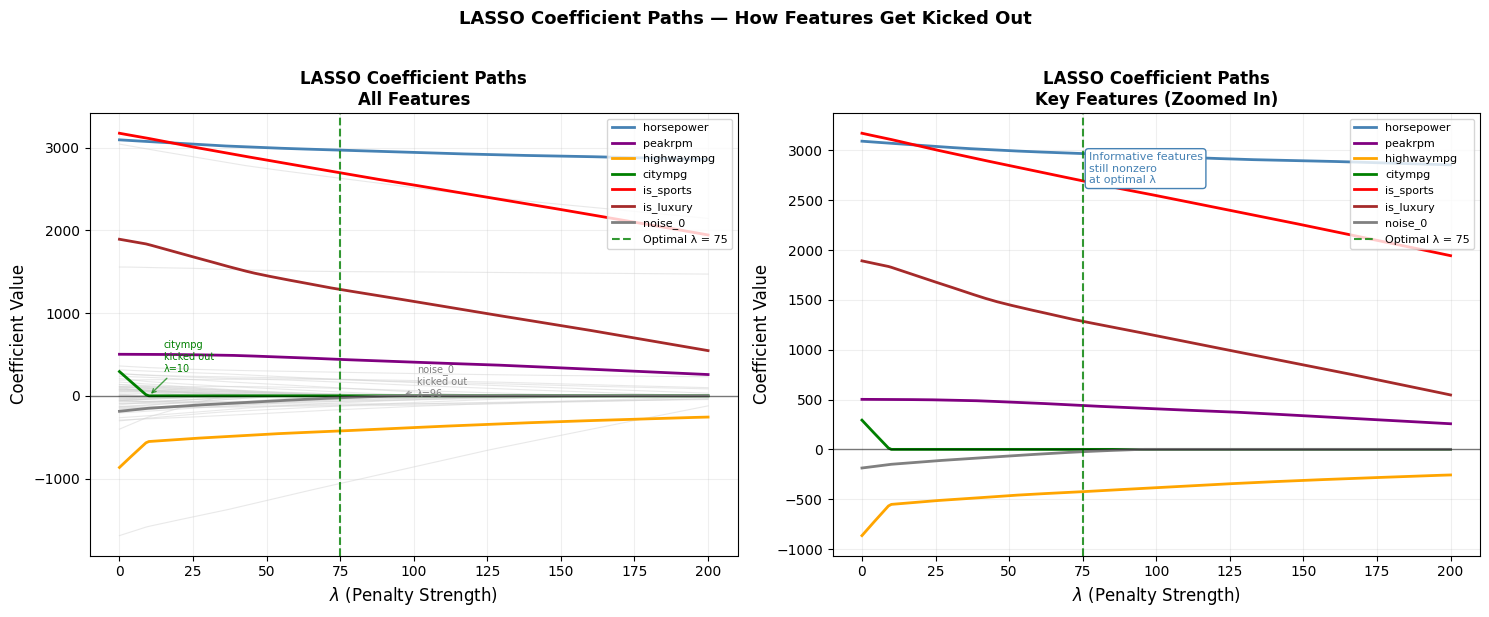

  Feature Status at Optimal λ = 75

  Survived (36 features):
    horsepower           coef = 2,967.8
    is_sports            coef = 2,693.3
    is_turbo             coef = 2,628.9
    enginesize           coef = 1,501.1
    is_luxury            coef = 1,284.9
    is_diesel            coef = -1,059.3
    peakrpm              coef = 439.8
    highwaympg           coef = -424.7
    wheelbase            coef = 284.5
    noise_48             coef = 199.6

  Kicked out (32 features) — includes:
    citympg
    curbweight
    is_awd
    noise_3
    noise_4
    noise_5
    noise_7
    noise_8
    noise_10
    noise_13
    ... and 22 more (mostly noise features)


In [48]:
# ── Plot LASSO Coefficient Paths ─────────────────────────────────────────────
# For each λ we already have the fitted model stored in lasso_models
# We can extract the coefficient on each feature across all λ values
# This shows us which features get kicked out and in what order

# ── Extract coefficient paths ────────────────────────────────────────────────
feature_names = list(X_train_scaled.columns)
coef_paths = np.array([model.coef_ for model in lasso_models])
# coef_paths shape: (n_lambdas, n_features)

# ── Identify which features to highlight ────────────────────────────────────
# We highlight the key informative features from our simulation
# and one example of a noise feature getting kicked out early
highlight_features = {
    'horsepower'  : 'steelblue',
    'peakrpm'     : 'purple',
    'highwaympg'  : 'orange',
    'citympg'     : 'green',
    'is_sports'   : 'red',
    'is_luxury'   : 'brown',
    'noise_0'     : 'gray',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left plot: All features (background) + highlighted features ──────────────
ax = axes[0]

# Plot all features in light gray in background
for i, feature in enumerate(feature_names):
    if feature not in highlight_features:
        ax.plot(lambdas, coef_paths[:, i],
                color='lightgray', lw=0.8, alpha=0.5)

# Plot highlighted features on top
for feature, color in highlight_features.items():
    if feature in feature_names:
        idx = feature_names.index(feature)
        coefs = coef_paths[:, idx]

        # Find where coefficient first hits zero
        zero_crossings = [lambdas[j] for j in range(len(lambdas))
                         if coefs[j] == 0.0]
        kicked_at = zero_crossings[0] if zero_crossings else None

        ax.plot(lambdas, coefs,
                color=color, lw=2, label=feature)

        # Annotate where feature gets kicked out
        if kicked_at is not None and kicked_at <= max(lambdas) * 0.85:
            kick_idx = lambdas.index(kicked_at)
            ax.annotate(f'{feature}\nkicked out\nλ={kicked_at}',
                        xy=(kicked_at, 0),
                        xytext=(kicked_at + 5, coef_paths[max(0,kick_idx-10), idx]),
                        fontsize=7, color=color,
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=1, alpha=0.7))

# Mark optimal lambda
ax.axvline(optimal_lambda, color='green',
           lw=1.5, linestyle='--', alpha=0.8,
           label=f'Optimal λ = {optimal_lambda}')
ax.axhline(0, color='black', lw=1.0, alpha=0.5)

ax.set_xlabel('$\\lambda$ (Penalty Strength)', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('LASSO Coefficient Paths\nAll Features',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)

# ── Right plot: Zoom in on highlighted features only ─────────────────────────
ax = axes[1]

for feature, color in highlight_features.items():
    if feature in feature_names:
        idx = feature_names.index(feature)
        ax.plot(lambdas, coef_paths[:, idx],
                color=color, lw=2, label=feature)

# Mark optimal lambda
ax.axvline(optimal_lambda, color='green',
           lw=1.5, linestyle='--', alpha=0.8,
           label=f'Optimal λ = {optimal_lambda}')
ax.axhline(0, color='black', lw=1.0, alpha=0.5)

# Annotate key observations
ax.text(optimal_lambda + 2,
        coef_paths[optimal_idx,
        feature_names.index('horsepower')] * 0.9,
        'Informative features\nstill nonzero\nat optimal λ ',
        fontsize=8, color='steelblue',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='steelblue'))

ax.set_xlabel('$\\lambda$ (Penalty Strength)', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('LASSO Coefficient Paths\nKey Features (Zoomed In)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)

plt.suptitle('LASSO Coefficient Paths — How Features Get Kicked Out',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary: which features survived at optimal λ ────────────────────────────
print("=" * 60)
print(f"  Feature Status at Optimal λ = {optimal_lambda}")
print("=" * 60)
survived = []
kicked   = []
for i, feature in enumerate(feature_names):
    if coef_paths[optimal_idx, i] != 0:
        survived.append((feature, coef_paths[optimal_idx, i]))
    else:
        kicked.append(feature)

print(f"\n  Survived ({len(survived)} features):")
for name, coef in sorted(survived, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"    {name:<20} coef = {coef:,.1f}")

print(f"\n  Kicked out ({len(kicked)} features) — includes:")
for name in kicked[:10]:
    print(f"    {name}")
if len(kicked) > 10:
    print(f"    ... and {len(kicked)-10} more (mostly noise features)")
print("=" * 60)

---
## Ridge Regression
### A Different Penalty, A Different Behavior

Recall LASSO modifies the OLS problem by penalizing the
**sum of absolute values** of the coefficients:

$$\min_{b_0, b_1, \ldots, b_k} \mathbb{E}\left[\left(Y - \left(b_0 + \sum_{i=1}^{k} b_i X_i\right)\right)^2\right] + \lambda\left(\sum_{i=1}^{k} |b_i|\right)$$

---

### The Ridge Modification

Ridge regression penalizes the **sum of squared coefficients** instead:

$$\min_{b_0, b_1, \ldots, b_k} \underbrace{\mathbb{E}\left[\left(Y - \left(b_0 + \sum_{i=1}^{k} b_i X_i\right)\right)^2\right]}_{\text{fit well (same as OLS)}} + \underbrace{\lambda\left(\sum_{i=1}^{k} b_i^2\right)}_{\text{stay small (squared penalty)}}$$

Same basic idea as LASSO — limiting coefficient size reduces
overfitting — but the **squaring** of the penalty changes everything.

---

### The Equivalent Constrained Form

Just like LASSO, Ridge can be written as a constrained problem:

$$\min_{b_0, b_1, \ldots, b_k} \mathbb{E}\left[\left(Y - \left(b_0 + \sum_{i=1}^{k} b_i X_i\right)\right)^2\right] \quad \text{subject to} \quad \sum_{i=1}^{k} b_i^2 \leq \kappa$$

Instead of a **diamond** constraint region (LASSO),
Ridge places a **circle** constraint region on $(b_1, b_2, \ldots, b_k)$.

---

### Why Ridge Almost Never Zeros Out Coefficients

This comes down to the math of the squared penalty.

**LASSO** — reducing a coefficient by 0.1 always contributes
the **same amount** to the minimization, regardless of its current size:

$$|1| - |0.9| = 0.1$$
$$|0.5| - |0.4| = 0.1$$
$$|0.1| - |0| = 0.1$$

→ LASSO maintains **constant pressure** to shrink all the way to zero.

**Ridge** — the value of reducing a coefficient by 0.1 **diminishes**
as the coefficient gets smaller:

$$1^2 - 0.9^2 = 0.19$$
$$0.5^2 - 0.4^2 = 0.09$$
$$0.1^2 - 0^2 = 0.01$$

→ As a coefficient approaches zero, the benefit of shrinking it
further becomes **negligible** — so Ridge almost never completes
the journey all the way to zero.

---

### The Geometry Revisited

Recall from abovethat the LASSO solution hits the **corner**
of the diamond constraint — setting one coefficient to exactly zero.

With Ridge, the constraint region is a **circle** — it has no corners.
The expanding prediction error ellipses hit the smooth circular
boundary at a point where **both coefficients are nonzero**:

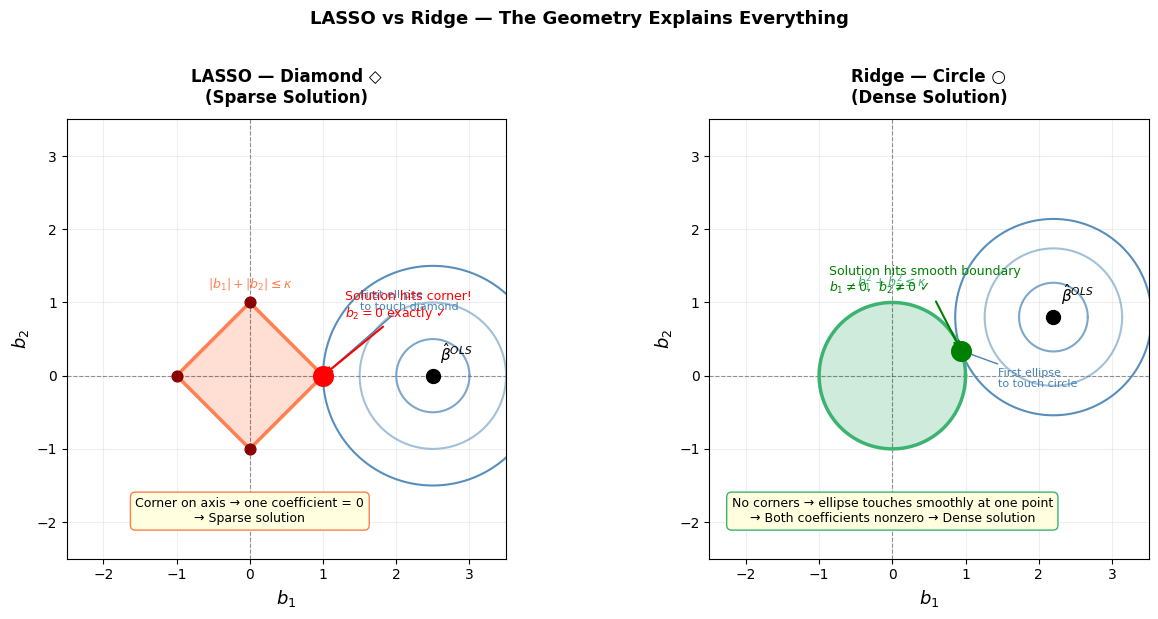

In [49]:


fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, title, shape in zip(axes,
                             ['LASSO — Diamond ◇\n(Sparse Solution)',
                              'Ridge — Circle ○\n(Dense Solution)'],
                             ['lasso', 'ridge']):

    ax.set_xlim(-2.5, 3.5)
    ax.set_ylim(-2.5, 3.5)
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
    ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel('$b_1$', fontsize=13)
    ax.set_ylabel('$b_2$', fontsize=13)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

    theta = np.linspace(0, 2*np.pi, 300)
    kappa = 1.0

    if shape == 'lasso':
        # ── OLS solution ─────────────────────────────────────────────────────
        ols = np.array([2.5, 0.0])
        ax.scatter(*ols, color='black', s=100, zorder=5)
        ax.annotate('$\\hat{\\beta}^{OLS}$', ols,
                    xytext=(ols[0]+0.1, ols[1]+0.2), fontsize=11)

        # ── Expanding circular ellipses ──────────────────────────────────────
        # Touching radius = distance from OLS to corner (1,0) = 2.5 - 1 = 1.5
        touch_r = 1.5
        for r, alpha in zip([0.5, 1.0, touch_r], [0.7, 0.5, 0.9]):
            ax.plot(ols[0] + r*np.cos(theta),
                    ols[1] + r*np.sin(theta),
                    color='steelblue', alpha=alpha, lw=1.5)

        ax.annotate('First ellipse\nto touch diamond',
                    xy=(1.0, 0.0),
                    xytext=(1.5, 0.9),
                    fontsize=8, color='steelblue',
                    arrowprops=dict(arrowstyle='->', color='steelblue'))

        # ── Diamond constraint ───────────────────────────────────────────────
        diamond_x = [kappa, 0, -kappa, 0, kappa]
        diamond_y = [0, kappa, 0, -kappa, 0]
        ax.fill(diamond_x, diamond_y, color='coral', alpha=0.25)
        ax.plot(diamond_x, diamond_y, color='coral', lw=2.5)
        ax.text(0, kappa+0.2, '$|b_1| + |b_2| \\leq \\kappa$',
                ha='center', fontsize=9, color='coral')

        # ── Corner points ────────────────────────────────────────────────────
        for cx, cy in [(kappa,0),(0,kappa),(-kappa,0),(0,-kappa)]:
            ax.scatter(cx, cy, color='darkred', s=60, zorder=6)

        # ── Solution at corner ───────────────────────────────────────────────
        sol = np.array([kappa, 0.0])
        ax.scatter(*sol, color='red', s=200, zorder=7)
        ax.annotate('Solution hits corner!\n'
                    '$b_2 = 0$ exactly ✓',
                    xy=sol,
                    xytext=(sol[0]+0.3, sol[1]+0.8),
                    fontsize=9, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

        ax.text(0, -2.0,
                'Corner on axis → one coefficient = 0\n→ Sparse solution',
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='lightyellow', ec='coral'))

    else:
        # ── OLS solution — off axis ──────────────────────────────────────────
        # Place OLS away from axes so solution hits smooth boundary
        ols = np.array([2.2, 0.8])
        ax.scatter(*ols, color='black', s=100, zorder=5)
        ax.annotate('$\\hat{\\beta}^{OLS}$', ols,
                    xytext=(ols[0]+0.1, ols[1]+0.2), fontsize=11)

        # ── Compute touching radius mathematically ───────────────────────────
        # Nearest point on unit circle to OLS is along the line origin → OLS
        # Touch radius = dist(OLS, origin) - kappa  →  guaranteed tangency
        ols_dist  = np.sqrt(ols[0]**2 + ols[1]**2)   # ≈ 2.341
        touch_r   = ols_dist - kappa                   # ≈ 1.341

        # Show two smaller ellipses and the exact touching one
        for r, alpha in zip([touch_r*0.35, touch_r*0.7, touch_r],
                             [0.7, 0.5, 0.9]):
            ax.plot(ols[0] + r*np.cos(theta),
                    ols[1] + r*np.sin(theta),
                    color='steelblue', alpha=alpha, lw=1.5)

        # ── Circle constraint ────────────────────────────────────────────────
        ax.fill(kappa*np.cos(theta),
                kappa*np.sin(theta),
                color='mediumseagreen', alpha=0.25)
        ax.plot(kappa*np.cos(theta),
                kappa*np.sin(theta),
                color='mediumseagreen', lw=2.5)
        ax.text(0, kappa+0.2, '$b_1^2 + b_2^2 \\leq \\kappa$',
                ha='center', fontsize=9, color='mediumseagreen')

        # ── Solution — nearest point on circle to OLS ────────────────────────
        # = OLS / |OLS| × kappa
        sol = (ols / ols_dist) * kappa   # guaranteed on circle boundary
        ax.scatter(*sol, color='green', s=200, zorder=7)

        ax.annotate('First ellipse\nto touch circle',
                    xy=sol,
                    xytext=(sol[0]+0.5, sol[1]-0.5),
                    fontsize=8, color='steelblue',
                    arrowprops=dict(arrowstyle='->', color='steelblue'))

        ax.annotate('Solution hits smooth boundary\n'
                    '$b_1 \\neq 0$,  $b_2 \\neq 0$ ✓',
                    xy=sol,
                    xytext=(sol[0]-1.8, sol[1]+0.8),
                    fontsize=9, color='green',
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

        ax.text(0, -2.0,
                'No corners → ellipse touches smoothly at one point\n'
                '→ Both coefficients nonzero → Dense solution',
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='lightyellow', ec='mediumseagreen'))

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle('LASSO vs Ridge — The Geometry Explains Everything',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### LASSO vs Ridge — Side by Side

| | LASSO | Ridge |
|---|---|---|
| **Penalty** | $\sum \|b_i\|$ (absolute) | $\sum b_i^2$ (squared) |
| **Constraint shape** | Diamond ◇ (has corners) | Circle ○ (smooth) |
| **Drives coefficients to 0?** | ✓ Yes — exactly zero | ✗ No — approaches but never reaches |
| **Shrinkage pressure** | Constant regardless of size | Diminishing as coefficient shrinks |
| **Result** | Sparse — kicks features out | Dense — shrinks all features |
| **Closed form solution?** | ✗ No — coordinate descent | ✓ Yes — like OLS |
| **Better when** | Many irrelevant features | Features correlated, all relevant |

---

### Correlated Features — A Key Difference

Recall from previous Recitation that **imperfect collinearity** inflates variance.
Both LASSO and Ridge address this — but differently:

- **LASSO** tends to pick one of the correlated features and kick
  the other out — but which one it keeps can be **arbitrary**
  and sensitive to the particular sample

- **Ridge** shrinks both correlated features simultaneously —
  keeping both but smaller — leading to more **stability**
  across different samples

> This is why Ridge tends to perform slightly better on
> **out-of-sample prediction** when features are correlated.

---

### A Note on Estimation

| | LASSO | Ridge |
|---|---|---|
| **Closed form?** | ✗ No | ✓ Yes |
| **How estimated?** | Coordinate descent (sklearn searches numerically) | Analytically — like OLS |
| **Coefficients unique?** | Not necessarily | Yes — always unique |
| **In practice** | Basically as fast as Ridge | Slightly faster in theory |

> The lack of a closed form for LASSO means different software
> packages can sometimes give slightly different answers —
> unlike OLS and Ridge which always give the same unique solution.

---
## Why a Diamond vs a Circle?

The shape of the constraint region comes directly from the
**math of the penalty term** — it is not arbitrary.

---

### LASSO Penalty → Diamond

The LASSO constraint is:

$$|b_1| + |b_2| \leq \kappa$$

Let's trace what this looks like geometrically. Set $\kappa = 1$
and ask: *what points $(b_1, b_2)$ satisfy this exactly?*

- Along $b_1$ axis ($b_2 = 0$): $|b_1| = 1$ → points $(\pm 1, 0)$
- Along $b_2$ axis ($b_1 = 0$): $|b_2| = 1$ → points $(0, \pm 1)$
- Between axes: $|b_1| + |b_2| = 1$ → a **straight line** connecting them

Straight lines connecting four axis points
→ gives you exactly a **diamond** ◇

The corners arise naturally because the penalty uses
**absolute values** — which have a kink at zero.

---

### Ridge Penalty → Circle

The Ridge constraint is:

$$b_1^2 + b_2^2 \leq \kappa$$

This is just the equation of a **circle** with radius $\sqrt{\kappa}$ —
you may recognize this from basic geometry:

$$x^2 + y^2 = r^2$$

The smooth round shape arises because the penalty uses
**squares** — which are smooth and symmetric in all directions.

---

### The Key Insight

| Penalty Type | Math Property | Shape |
|---|---|---|
| Absolute value $\|b\|$ | Has a **kink** at zero | Diamond ◇ with corners |
| Squared $b^2$ | **Smooth** everywhere | Circle ○ with no corners |

> The kink in the absolute value is precisely what creates the corners
> on the diamond — and those corners are what forces LASSO solutions
> to land on the axes, setting coefficients to exactly zero.
>
> Ridge uses squares which are smooth everywhere — no kinks,
> no corners, no zeros.

This is why the **choice of penalty is not cosmetic** —
it fundamentally determines the geometry of the solution
and whether features get kicked out or just shrunk.

In [50]:
# ── Loop Over λ Values, Fit Ridge, Record Test MSE ───────────────────────────
# Same loop pattern as LASSO — just swap Lasso for Ridge
# Note: Ridge uses a different scale of λ than LASSO
# Ridge optimal λ is often much smaller — so we use a finer grid

ridge_lambdas = [i/10 for i in range(0, 201)]  # 0.0 to 20.0 in steps of 0.1

ridge_mse    = []   # store test MSE for each λ
ridge_models = []   # store fitted models for coefficient paths later

for lam in ridge_lambdas:

    # ── Step 1: Fit Ridge on training set ───────────────────────────────────
    # alpha in sklearn = λ in our notation
    ridge = Ridge(alpha=max(lam, 1e-6),  # avoid exact 0
                  random_state=42)

    ridge.fit(X_train_scaled, y_train)

    # ── Step 2: Predict on test set ─────────────────────────────────────────
    y_pred = ridge.predict(X_test_scaled)

    # ── Step 3: Record test MSE ─────────────────────────────────────────────
    mse = mean_squared_error(y_test, y_pred)
    ridge_mse.append(mse)
    ridge_models.append(ridge)

# ── Find Optimal λ for Ridge ─────────────────────────────────────────────────
ridge_optimal_idx    = np.argmin(ridge_mse)
ridge_optimal_lambda = ridge_lambdas[ridge_optimal_idx]
ridge_optimal_mse    = ridge_mse[ridge_optimal_idx]

print("=" * 60)
print(f"  Ridge Results")
print("=" * 60)
print(f"  λ = 0     (OLS)    Test MSE : {ridge_mse[0]:,.0f}")
print(f"  Optimal λ          : {ridge_optimal_lambda}")
print(f"  Optimal Test MSE   : {ridge_optimal_mse:,.0f}")
print(f"  λ = {max(ridge_lambdas)}           Test MSE : {ridge_mse[-1]:,.0f}")
print("=" * 60)

# ── Compare LASSO vs Ridge ───────────────────────────────────────────────────
print(f"\n  LASSO vs Ridge Comparison")
print("=" * 60)
print(f"  {'':20}  {'LASSO':>15}  {'Ridge':>15}")
print(f"  {'Optimal λ':20}  {optimal_lambda:>15}  {ridge_optimal_lambda:>15}")
print(f"  {'Optimal Test MSE':20}  {optimal_mse:>15,.0f}  {ridge_optimal_mse:>15,.0f}")
winner = 'Ridge' if ridge_optimal_mse < optimal_mse else 'LASSO'
print(f"\n  Winner (lower MSE): {winner} ")
print("=" * 60)

  Ridge Results
  λ = 0     (OLS)    Test MSE : 4,920,827
  Optimal λ          : 1.8
  Optimal Test MSE   : 4,905,771
  λ = 20.0           Test MSE : 5,413,467

  LASSO vs Ridge Comparison
                                  LASSO            Ridge
  Optimal λ                          75              1.8
  Optimal Test MSE            3,654,163        4,905,771

  Winner (lower MSE): LASSO 


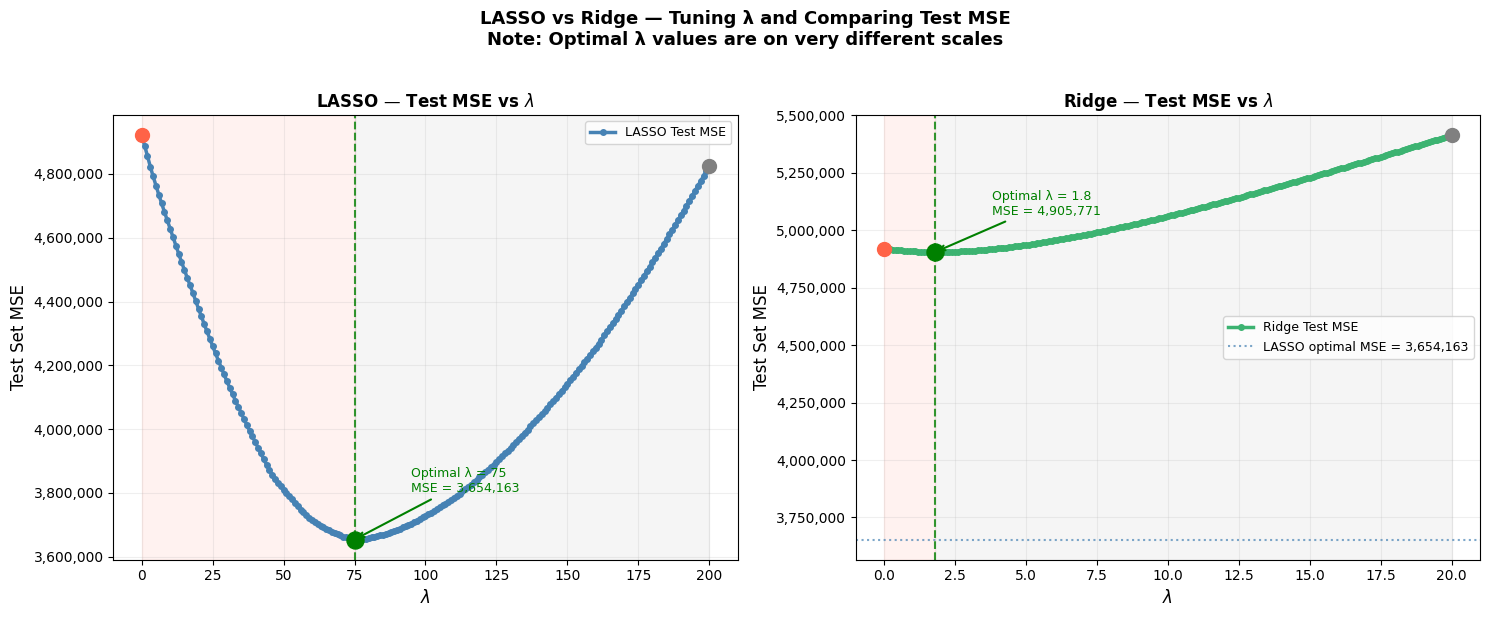


Key Observations:
  1. LASSO optimal λ ≈ 75 vs Ridge optimal λ ≈ 1.8
     → Ridge operates on a much smaller scale of λ
       because squared penalties are inherently larger
       than absolute value penalties

  2. LASSO achieves lower test MSE in this dataset
     → Consistent with theory: Ridge tends to win
       when features are correlated (city/highway MPG)


In [51]:
# ── Plot LASSO vs Ridge Test MSE Side by Side ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left plot: LASSO MSE curve ───────────────────────────────────────────────
ax = axes[0]
ax.plot(lambdas, lasso_mse,
        color='steelblue', lw=2.5, marker='o',
        markersize=4, label='LASSO Test MSE')

ax.axvspan(0, optimal_lambda,
           alpha=0.08, color='tomato')
ax.axvspan(optimal_lambda, max(lambdas),
           alpha=0.08, color='gray')

ax.axvline(optimal_lambda, color='green',
           lw=1.5, linestyle='--', alpha=0.8)
ax.scatter([optimal_lambda], [optimal_mse],
           color='green', s=150, zorder=5)
ax.annotate(f'Optimal λ = {optimal_lambda}\n'
            f'MSE = {optimal_mse:,.0f}',
            xy=(optimal_lambda, optimal_mse),
            xytext=(optimal_lambda + max(lambdas)*0.1,
                    optimal_mse + max(lasso_mse)*0.03),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

ax.scatter([0], [lasso_mse[0]], color='tomato', s=100, zorder=5)
ax.scatter([max(lambdas)], [lasso_mse[-1]], color='gray', s=100, zorder=5)

ax.set_xlabel('$\\lambda$', fontsize=12)
ax.set_ylabel('Test Set MSE', fontsize=12)
ax.set_title('LASSO — Test MSE vs $\\lambda$',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, alpha=0.2)
ax.legend(fontsize=9)

# ── Right plot: Ridge MSE curve ──────────────────────────────────────────────
ax = axes[1]
ax.plot(ridge_lambdas, ridge_mse,
        color='mediumseagreen', lw=2.5, marker='o',
        markersize=4, label='Ridge Test MSE')

ax.axvspan(0, ridge_optimal_lambda,
           alpha=0.08, color='tomato')
ax.axvspan(ridge_optimal_lambda, max(ridge_lambdas),
           alpha=0.08, color='gray')

ax.axvline(ridge_optimal_lambda, color='green',
           lw=1.5, linestyle='--', alpha=0.8)
ax.scatter([ridge_optimal_lambda], [ridge_optimal_mse],
           color='green', s=150, zorder=5)
ax.annotate(f'Optimal λ = {ridge_optimal_lambda}\n'
            f'MSE = {ridge_optimal_mse:,.0f}',
            xy=(ridge_optimal_lambda, ridge_optimal_mse),
            xytext=(ridge_optimal_lambda + max(ridge_lambdas)*0.1,
                    ridge_optimal_mse + max(ridge_mse)*0.03),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

ax.scatter([0], [ridge_mse[0]], color='tomato', s=100, zorder=5)
ax.scatter([max(ridge_lambdas)], [ridge_mse[-1]], color='gray', s=100, zorder=5)

# ── Add horizontal line showing LASSO optimal MSE for comparison ─────────────
ax.axhline(optimal_mse, color='steelblue', lw=1.5,
           linestyle=':', alpha=0.7,
           label=f'LASSO optimal MSE = {optimal_mse:,.0f}')

ax.set_xlabel('$\\lambda$', fontsize=12)
ax.set_ylabel('Test Set MSE', fontsize=12)
ax.set_title('Ridge — Test MSE vs $\\lambda$',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, alpha=0.2)
ax.legend(fontsize=9)

plt.suptitle('LASSO vs Ridge — Tuning λ and Comparing Test MSE\n'
             'Note: Optimal λ values are on very different scales',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Key observation ──────────────────────────────────────────────────────────
print("\nKey Observations:")
print(f"  1. LASSO optimal λ ≈ {optimal_lambda} vs"
      f" Ridge optimal λ ≈ {ridge_optimal_lambda}")
print(f"     → Ridge operates on a much smaller scale of λ")
print(f"       because squared penalties are inherently larger")
print(f"       than absolute value penalties")
print(f"\n  2. {winner} achieves lower test MSE in this dataset")
print(f"     → Consistent with theory: Ridge tends to win")
print(f"       when features are correlated (city/highway MPG)")

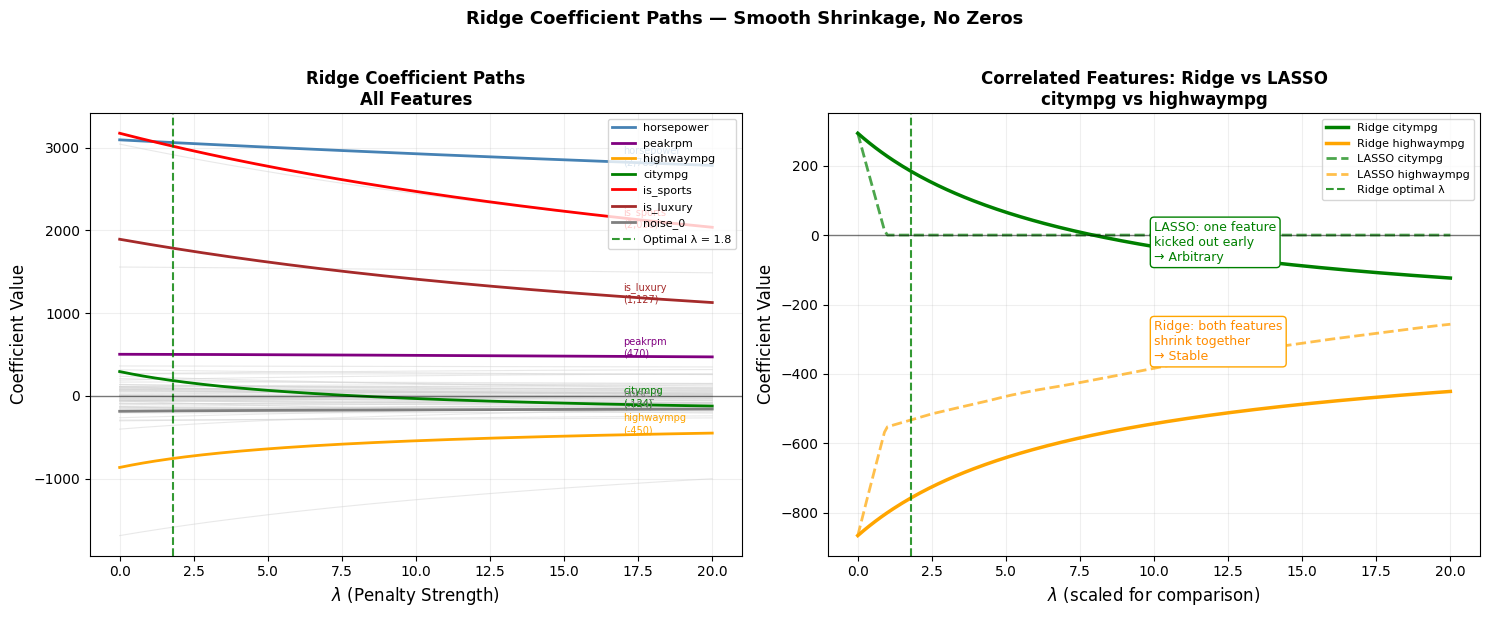

  Ridge Coefficient Summary at Optimal λ = 1.8

  Key features — coefficient values:
  horsepower           LASSO:    2,967.8   Ridge:    3,059.4
  peakrpm              LASSO:      439.8   Ridge:      500.7
  highwaympg           LASSO:     -424.7   Ridge:     -756.7
  citympg              LASSO:       -0.0   Ridge:      183.5
  is_sports            LASSO:    2,693.3   Ridge:    3,015.4
  is_luxury            LASSO:    1,284.9   Ridge:    1,783.6
  noise_0              LASSO:      -23.1   Ridge:     -181.9

  Features at exactly zero in Ridge: 0
  Features at exactly zero in LASSO: 32

  → Ridge keeps all features, just shrinks them
  → LASSO zeros out uninformative features entirely 


In [52]:
# ── Plot Ridge Coefficient Paths ─────────────────────────────────────────────
# Same structure as LASSO coefficient paths (Cell 10)
# Key difference to observe:
# → Ridge coefficients shrink smoothly but NEVER hit zero
# → Correlated features (citympg, highwaympg) both kept — not one kicked out

# ── Extract Ridge coefficient paths ──────────────────────────────────────────
ridge_coef_paths = np.array([model.coef_ for model in ridge_models])
# shape: (n_lambdas, n_features)

# Same features as before for direct comparison with LASSO
highlight_features = {
    'horsepower'  : 'steelblue',
    'peakrpm'     : 'purple',
    'highwaympg'  : 'orange',
    'citympg'     : 'green',
    'is_sports'   : 'red',
    'is_luxury'   : 'brown',
    'noise_0'     : 'gray',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left plot: Ridge coefficient paths ───────────────────────────────────────
ax = axes[0]

# All features in light gray background
for i, feature in enumerate(feature_names):
    if feature not in highlight_features:
        ax.plot(ridge_lambdas, ridge_coef_paths[:, i],
                color='lightgray', lw=0.8, alpha=0.5)

# Highlighted features on top
for feature, color in highlight_features.items():
    if feature in feature_names:
        idx   = feature_names.index(feature)
        coefs = ridge_coef_paths[:, idx]
        ax.plot(ridge_lambdas, coefs,
                color=color, lw=2, label=feature)

        # Annotate final value at max lambda
        ax.annotate(f'{feature}\n({coefs[-1]:,.0f})',
                    xy=(max(ridge_lambdas), coefs[-1]),
                    xytext=(max(ridge_lambdas)-3, coefs[-1]),
                    fontsize=7, color=color)

# Mark optimal lambda
ax.axvline(ridge_optimal_lambda, color='green',
           lw=1.5, linestyle='--', alpha=0.8,
           label=f'Optimal λ = {ridge_optimal_lambda}')
ax.axhline(0, color='black', lw=1.0, alpha=0.5)

ax.set_xlabel('$\\lambda$ (Penalty Strength)', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Ridge Coefficient Paths\nAll Features',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)

# ── Right plot: LASSO vs Ridge side by side for correlated features ───────────
# Focus on citympg vs highwaympg — the most interesting comparison
ax = axes[1]

correlated_features = {
    'citympg'    : ('green',  'solid',  'Ridge citympg'),
    'highwaympg' : ('orange', 'solid',  'Ridge highwaympg'),
}

lasso_correlated = {
    'citympg'    : ('green',  'dashed', 'LASSO citympg'),
    'highwaympg' : ('orange', 'dashed', 'LASSO highwaympg'),
}

# Plot Ridge paths for correlated features
for feature, (color, ls, label) in correlated_features.items():
    if feature in feature_names:
        idx = feature_names.index(feature)
        ax.plot(ridge_lambdas,
                ridge_coef_paths[:, idx],
                color=color, lw=2.5,
                linestyle=ls, label=label)

# Normalize LASSO lambdas to same x scale for comparison
# Plot LASSO paths for same features
for feature, (color, ls, label) in lasso_correlated.items():
    if feature in feature_names:
        idx = feature_names.index(feature)
        # Scale LASSO lambdas to Ridge lambda range for visual comparison
        lasso_x = [l * (max(ridge_lambdas)/max(lambdas))
                   for l in lambdas]
        ax.plot(lasso_x,
                coef_paths[:, idx],
                color=color, lw=2,
                linestyle=ls, label=label,
                alpha=0.7)

ax.axvline(ridge_optimal_lambda, color='green',
           lw=1.5, linestyle='--', alpha=0.8,
           label=f'Ridge optimal λ')
ax.axhline(0, color='black', lw=1.0, alpha=0.5)

# Annotate key observations
ax.text(max(ridge_lambdas)*0.5,
        max(ridge_coef_paths[:,
            feature_names.index('highwaympg')]) * 0.8,
        'Ridge: both features\nshrink together\n→ Stable ',
        fontsize=9, color='darkorange',
        bbox=dict(boxstyle='round,pad=0.3',
                  fc='white', ec='orange'))

ax.text(max(ridge_lambdas)*0.5,
        min(ridge_coef_paths[:,
            feature_names.index('citympg')]) * 0.6,
        'LASSO: one feature\nkicked out early\n→ Arbitrary ',
        fontsize=9, color='green',
        bbox=dict(boxstyle='round,pad=0.3',
                  fc='white', ec='green'))

ax.set_xlabel('$\\lambda$ (scaled for comparison)', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Correlated Features: Ridge vs LASSO\n'
             'citympg vs highwaympg',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)

plt.suptitle('Ridge Coefficient Paths — Smooth Shrinkage, No Zeros',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"  Ridge Coefficient Summary at Optimal λ = {ridge_optimal_lambda}")
print("=" * 60)

print(f"\n  Key features — coefficient values:")
for feature, color in highlight_features.items():
    if feature in feature_names:
        idx      = feature_names.index(feature)
        lasso_c  = coef_paths[optimal_idx, idx]
        ridge_c  = ridge_coef_paths[ridge_optimal_idx, idx]
        print(f"  {feature:<20} "
              f"LASSO: {lasso_c:>10,.1f}   "
              f"Ridge: {ridge_c:>10,.1f}")

print(f"\n  Features at exactly zero in Ridge: "
      f"{np.sum(ridge_coef_paths[ridge_optimal_idx] == 0)}")
print(f"  Features at exactly zero in LASSO: "
      f"{np.sum(coef_paths[optimal_idx] == 0)}")
print(f"\n  → Ridge keeps all features, just shrinks them")
print(f"  → LASSO zeros out uninformative features entirely ")
print("=" * 60)

---
## When To Use Which Method?
### A Decision Framework

So far we have three shrinkage methods available:
- **LASSO** — absolute value penalty, sparse solutions
- **Ridge** — squared penalty, dense solutions  
- **Elastic Net** — both penalties combined (introduced next)

The choice between them is not arbitrary — it follows from
the **structure of your data and your goal**.

---

### Step 1 — What Is Your Goal?

The first question to ask is always: *what am I trying to do?*

**Causal Inference**
> "I want to estimate the causal effect of $X$ on $Y$"

Shrinkage methods are **not designed for causal inference**.
They optimize for prediction, not identification. Specifically:

- LASSO/Ridge coefficients are **biased by construction** —
  the penalty deliberately pulls them away from the true values
- Which features get kept or kicked out is driven by
  **predictive power**, not causal relevance
- A confound that is highly correlated with $X$ might get
  kicked out by LASSO — reintroducing OVB

> For causal inference: think carefully about your control
> variables using the OVB framework from Recitation 6 first.
> Shrinkage methods can help select among many candidate
> controls, but the causal reasoning must come from you.

**Prediction**
> "I want to predict $Y$ as accurately as possible
> for new observations"

This is where shrinkage methods shine. Proceed to Step 2.

---

### Step 2 — How Many Features, and Are They Relevant?

| Situation | Recommended Method | Why |
|---|---|---|
| Many features, most likely **irrelevant** | **LASSO** | Sparsity — kicks out uninformative features automatically |
| Many features, most likely **all relevant** | **Ridge** | Keeps all features, just shrinks them |
| Features are **highly correlated** | **Ridge** | More stable — shrinks correlated features together rather than arbitrarily keeping one |
| Want **interpretability** — know which features matter | **LASSO** | Zero = excluded, nonzero = informative |
| Very large number of features ($k$ very large) with correlations | **Elastic Net** | Combines sparsity of LASSO with stability of Ridge |
| Unsure | **Try all three** | Tune λ for each via train/test split, pick lowest test MSE |

---

### Step 3 — The Math Behind the Choice

The difference between methods comes down to what they
optimize — and what that implies for your coefficients:

**LASSO:**
$$\hat{\beta}^{LASSO} = \arg\min \left\{ \mathbb{E}\left[(Y - X\beta)^2\right] + \lambda\sum_{i=1}^{k}|\beta_i| \right\}$$

- Introduces **bias** proportional to $\lambda$
- Reduces **variance** by kicking out noisy features
- Best when true model is **sparse** (few features truly matter)

**Ridge:**
$$\hat{\beta}^{Ridge} = \arg\min \left\{ \mathbb{E}\left[(Y - X\beta)^2\right] + \lambda\sum_{i=1}^{k}\beta_i^2 \right\}$$

- Introduces **bias** proportional to $\lambda$
- Reduces **variance** by shrinking all features together
- Best when true model is **dense** (many features matter a little)

**The Bias-Variance Tradeoff in Both Cases:**
$$\text{Test MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

Both methods accept more bias in exchange for less variance.
The question is *which kind* of bias-variance tradeoff
fits your data structure better.

---

### Step 4 — Practical Checklist

Before running any shrinkage method, ask yourself:
```
□ Have I standardized continuous features?
  (If not → LASSO/Ridge will penalize unfairly by scale)

□ Have I left indicator variables unstandardized?
  (Standardizing dummies distorts their interpretation)

□ Have I fitted the scaler on training data only?
  (If not → data leakage)

□ Have I tuned λ via train/test split?
  (If not → you don't have the optimal model)

□ Have I checked the full U-shaped MSE curve?
  (If optimal λ is at the edge → extend your search range)

□ Am I interpreting coefficients causally?
  (If yes → shrinkage methods are not appropriate alone)
```

---

### Summary Table

| | OLS | LASSO | Ridge | Elastic Net |
|---|---|---|---|---|
| **Penalty** | None | $\sum\|b_i\|$ | $\sum b_i^2$ | Both |
| **Bias** | None | Yes | Yes | Yes |
| **Variance** | High | Lower | Lower | Lower |
| **Zeros out features?** | No | ✓ Yes | ✗ No | Sometimes |
| **Closed form?** | ✓ Yes | ✗ No | ✓ Yes | ✗ No |
| **Hyperparameters** | None | $\lambda$ | $\lambda$ | $\lambda_1, \lambda_2$ |
| **Best for** | Causal inference | Sparse prediction | Dense/correlated prediction | Very high dimensional |
| **Correlated features** | High variance | Arbitrary choice | Stable shrinkage | Stable + sparse |

## Elastic Net
### Combining the Best of Both Worlds

So far we have seen two shrinkage methods:
- **LASSO** — absolute value penalty → sparse solutions
- **Ridge** — squared penalty → stable, dense solutions

**Elastic Net** combines both penalties simultaneously:

$$\min_{b_0, b_1, \ldots, b_k} \underbrace{\mathbb{E}\left[\left(Y - \left(b_0 + \sum_{i=1}^{k} b_i X_i\right)\right)^2\right]}_{\text{fit well}} + \underbrace{\lambda_1\left(\sum_{i=1}^{k} |b_i|\right)}_{\text{LASSO penalty}} + \underbrace{\lambda_2\left(\sum_{i=1}^{k} b_i^2\right)}_{\text{Ridge penalty}}$$

---

### Two Hyperparameters

Elastic Net has **two hyperparameters** to tune:

| Hyperparameter | Role |
|---|---|
| $\lambda_1$ | Controls LASSO-type penalization → drives sparsity |
| $\lambda_2$ | Controls Ridge-type penalization → drives stability |

This means tuning happens in **two dimensions** simultaneously —
instead of searching over a 1D grid of λ values like before,
we search over a 2D grid of $(\lambda_1, \lambda_2)$ pairs.

In practice, `sklearn` handles this automatically via
`ElasticNet` and `ElasticNetCV`.

---

### What Does Elastic Net Actually Do?

Elastic Net inherits the best properties of both methods:

**From LASSO:**
- Encourages **sparsity** — some coefficients driven to zero
- Performs automatic **feature selection**

**From Ridge:**
- Encourages **stability** — correlated features shrink together
- More **robust** than LASSO when features are highly correlated

> Intuitively: Elastic Net will shrink correlated features
> simultaneously (like Ridge) before eventually kicking them
> all out together (like LASSO) — rather than arbitrarily
> keeping one and dropping the other.

---

### When Does Elastic Net Help?

For most typical datasets with moderate numbers of features,
Elastic Net does **not** offer a substantial improvement over
LASSO or Ridge on their own.

Elastic Net tends to shine in **very high dimensional** settings:

| Setting | Example | Why Elastic Net Helps |
|---|---|---|
| $k$ very large | Genomics — millions of gene predictors | LASSO side handles sparsity at scale |
| Many correlated features | Gene expression data — genes in same pathway | Ridge side stabilizes correlated groups |
| Groups of related features | Text analysis — related words | Tends to keep or drop whole groups |

**The Genomics Example:**
- Predictor variables are individual genes — potentially millions
- Many genes are correlated (same biological pathway)
- Most genes are irrelevant (need sparsity from LASSO side)
- But among relevant genes, correlations need handling (need Ridge side)
- → Elastic Net handles both simultaneously

---

### The Constraint Region

The Elastic Net constraint region is a **combination** of the
diamond and circle — a shape sometimes called a
**"squircle"** — it has rounded corners rather than sharp ones:

- Rounder than LASSO's diamond → more stability than LASSO
- More cornered than Ridge's circle → more sparsity than Ridge
- As $\lambda_1 \to 0$ → approaches pure Ridge (circle)
- As $\lambda_2 \to 0$ → approaches pure LASSO (diamond)

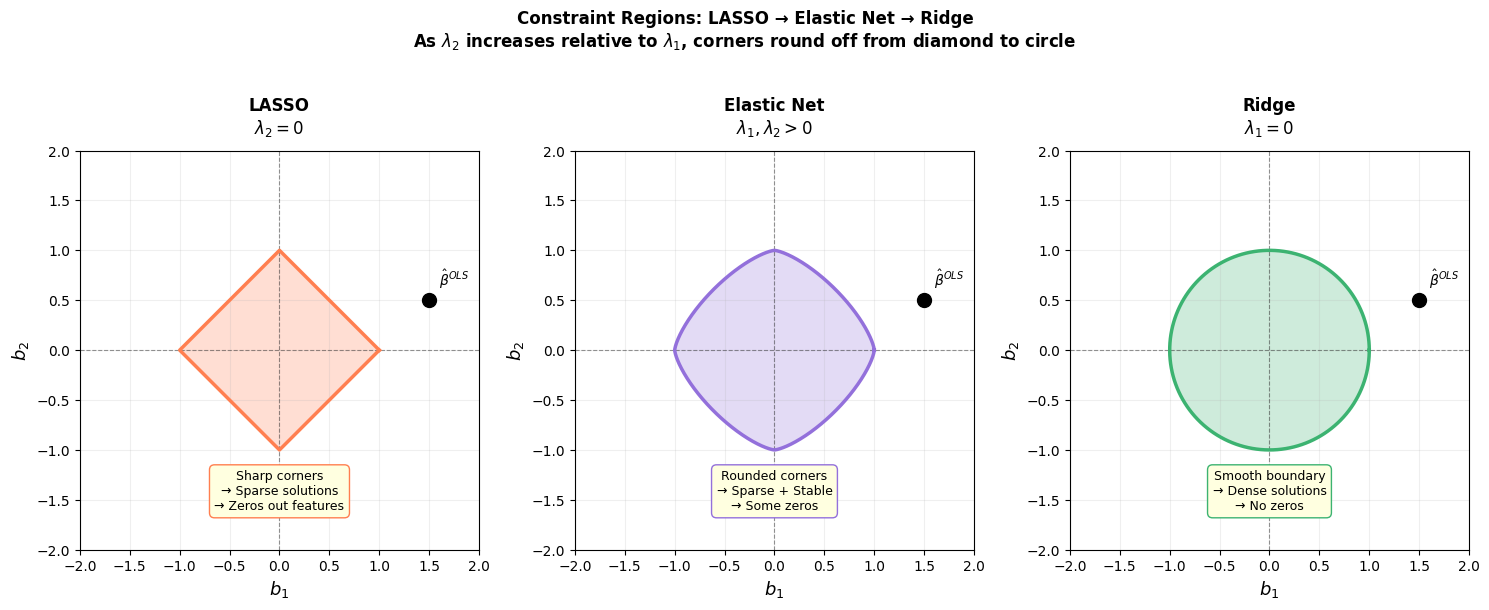

In [53]:

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

theta = np.linspace(0, 2*np.pi, 300)
kappa = 1.0

configs = [
    ('LASSO\n$\\lambda_2 = 0$',     'coral',          'lasso'),
    ('Elastic Net\n$\\lambda_1, \\lambda_2 > 0$', 'mediumpurple', 'enet'),
    ('Ridge\n$\\lambda_1 = 0$',     'mediumseagreen', 'ridge'),
]

for ax, (title, color, shape) in zip(axes, configs):

    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-2.0, 2.0)
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
    ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel('$b_1$', fontsize=13)
    ax.set_ylabel('$b_2$', fontsize=13)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

    if shape == 'lasso':
        # Diamond
        diamond_x = [kappa, 0, -kappa, 0, kappa]
        diamond_y = [0, kappa, 0, -kappa, 0]
        ax.fill(diamond_x, diamond_y, color=color, alpha=0.25)
        ax.plot(diamond_x, diamond_y, color=color, lw=2.5)
        ax.text(0, -1.6,
                'Sharp corners\n→ Sparse solutions\n→ Zeros out features',
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='lightyellow', ec=color))

    elif shape == 'ridge':
        # Circle
        ax.fill(kappa*np.cos(theta),
                kappa*np.sin(theta),
                color=color, alpha=0.25)
        ax.plot(kappa*np.cos(theta),
                kappa*np.sin(theta),
                color=color, lw=2.5)
        ax.text(0, -1.6,
                'Smooth boundary\n→ Dense solutions\n→ No zeros',
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='lightyellow', ec=color))

    else:
        # Elastic Net — superellipse (squircle)
        # |b1|^p + |b2|^p = 1 with p between 1 and 2
        # p=1 → diamond, p=2 → circle, p=1.4 → elastic net
        p = 1.4
        t = np.linspace(0, 2*np.pi, 1000)

        # Parametric squircle
        enet_x = np.sign(np.cos(t)) * np.abs(np.cos(t))**(2/p)
        enet_y = np.sign(np.sin(t)) * np.abs(np.sin(t))**(2/p)

        ax.fill(enet_x, enet_y, color=color, alpha=0.25)
        ax.plot(enet_x, enet_y, color=color, lw=2.5)
        ax.text(0, -1.6,
                'Rounded corners\n→ Sparse + Stable\n→ Some zeros',
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='lightyellow', ec=color))

    # OLS solution — same for all
    ols = np.array([1.5, 0.5])
    ax.scatter(*ols, color='black', s=100, zorder=5)
    ax.annotate('$\\hat{\\beta}^{OLS}$', ols,
                xytext=(ols[0]+0.1, ols[1]+0.15), fontsize=10)

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle('Constraint Regions: LASSO → Elastic Net → Ridge\n'
             'As $\\lambda_2$ increases relative to $\\lambda_1$, '
             'corners round off from diamond to circle',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Key Takeaways — Elastic Net

| | LASSO | Elastic Net | Ridge |
|---|---|---|---|
| **Constraint shape** | Diamond ◇ | Rounded diamond | Circle ○ |
| **Zeros out features?** | ✓ Yes | Sometimes | ✗ No |
| **Stable with correlations?** | ✗ No | ✓ Yes | ✓ Yes |
| **Hyperparameters** | 1 ($\lambda$) | 2 ($\lambda_1, \lambda_2$) | 1 ($\lambda$) |
| **Best use case** | Sparse problems | Very high dimensional | Correlated features |

> For most standard datasets: start with LASSO and Ridge.
> Move to Elastic Net only when $k$ is very large or
> you have strong groups of correlated features.

In [54]:


# ── Elastic Net — Tuning Two Hyperparameters Simultaneously ──────────────────
# Unlike LASSO and Ridge which have one λ each,
# Elastic Net has two: λ1 (LASSO side) and λ2 (Ridge side)
# We search over a 2D grid of (λ1, λ2) pairs

# ── Define search grid ───────────────────────────────────────────────────────
lambda1_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
lambda2_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

# Store results
results = []

for l1 in lambda1_values:
    for l2 in lambda2_values:

        # sklearn ElasticNet uses alpha and l1_ratio instead of λ1, λ2 directly
        # alpha      = λ1 + λ2          (total penalty strength)
        # l1_ratio   = λ1 / (λ1 + λ2)  (fraction that is LASSO-type)
        alpha    = l1 + l2
        l1_ratio = l1 / (l1 + l2)

        enet = ElasticNet(alpha=alpha,
                          l1_ratio=l1_ratio,
                          max_iter=10000,
                          random_state=42)

        enet.fit(X_train_scaled, y_train)
        y_pred = enet.predict(X_test_scaled)
        mse    = mean_squared_error(y_test, y_pred)

        results.append({
            'lambda1'  : l1,
            'lambda2'  : l2,
            'alpha'    : alpha,
            'l1_ratio' : l1_ratio,
            'mse'      : mse,
            'model'    : enet
        })

# ── Find optimal combination ─────────────────────────────────────────────────
results_df   = pd.DataFrame([{k:v for k,v in r.items()
                               if k != 'model'} for r in results])
optimal_row  = results_df.loc[results_df['mse'].idxmin()]
optimal_enet = results[results_df['mse'].idxmin()]['model']

print("=" * 60)
print(f"  Elastic Net Results")
print("=" * 60)
print(f"  Optimal λ1 (LASSO side) : {optimal_row['lambda1']}")
print(f"  Optimal λ2 (Ridge side) : {optimal_row['lambda2']}")
print(f"  Optimal Test MSE        : {optimal_row['mse']:,.0f}")
print("=" * 60)
print(f"\n  Comparison:")
print(f"  {'Method':<15} {'Optimal MSE':>15}")
print(f"  {'LASSO':<15} {optimal_mse:>15,.0f}")
print(f"  {'Ridge':<15} {ridge_optimal_mse:>15,.0f}")
print(f"  {'Elastic Net':<15} {optimal_row['mse']:>15,.0f}")
winner = min([('LASSO', optimal_mse),
              ('Ridge', ridge_optimal_mse),
              ('Elastic Net', optimal_row['mse'])],
             key=lambda x: x[1])
print(f"\n  Winner: {winner[0]} with MSE = {winner[1]:,.0f} ")
print("=" * 60)

  Elastic Net Results
  Optimal λ1 (LASSO side) : 50.0
  Optimal λ2 (Ridge side) : 0.01
  Optimal Test MSE        : 3,891,694

  Comparison:
  Method              Optimal MSE
  LASSO                 3,654,163
  Ridge                 4,905,771
  Elastic Net           3,891,694

  Winner: LASSO with MSE = 3,654,163 


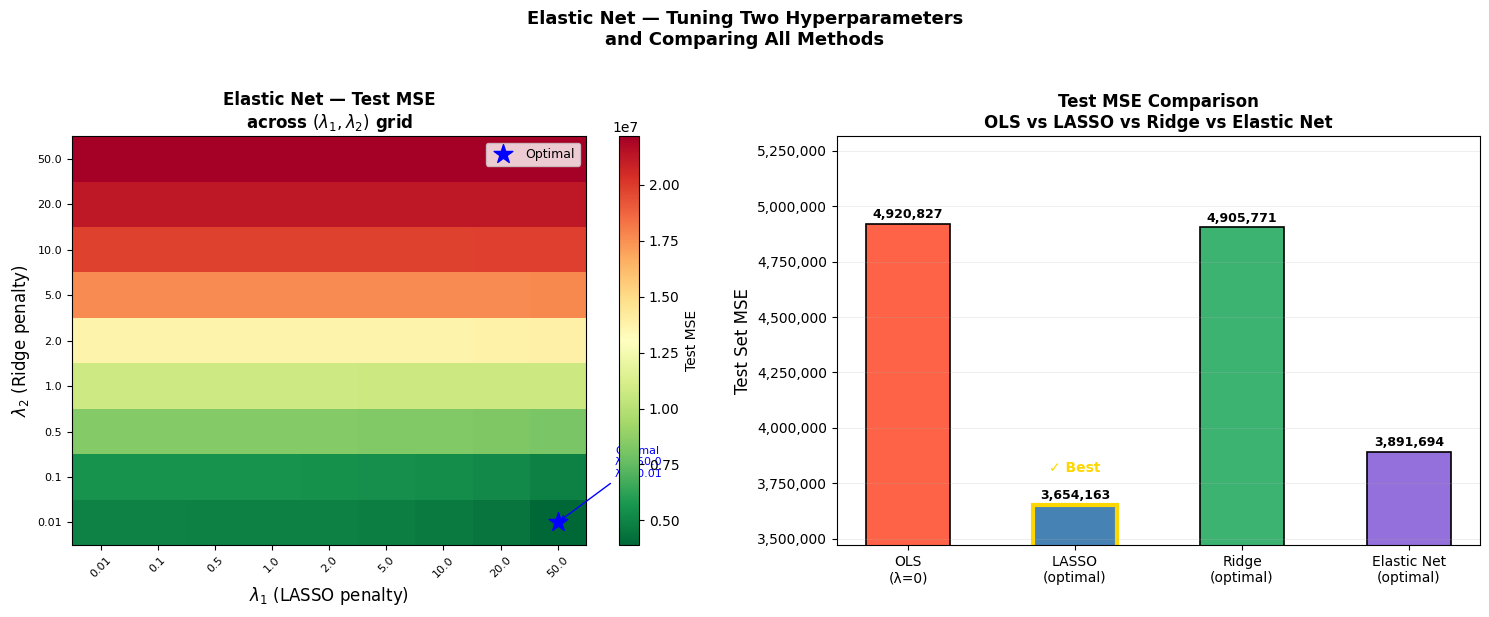

In [55]:
# ── Plot 1: Heatmap of Test MSE across (λ1, λ2) grid ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: Heatmap ────────────────────────────────────────────────────────────
ax = axes[0]

mse_grid = results_df.pivot(index='lambda2',
                             columns='lambda1',
                             values='mse')

im = ax.imshow(mse_grid.values,
               aspect='auto',
               cmap='RdYlGn_r',
               origin='lower')

ax.set_xticks(range(len(lambda1_values)))
ax.set_yticks(range(len(lambda2_values)))
ax.set_xticklabels([str(l) for l in lambda1_values],
                   rotation=45, fontsize=8)
ax.set_yticklabels([str(l) for l in lambda2_values],
                   fontsize=8)

ax.set_xlabel('$\\lambda_1$ (LASSO penalty)', fontsize=12)
ax.set_ylabel('$\\lambda_2$ (Ridge penalty)', fontsize=12)
ax.set_title('Elastic Net — Test MSE\nacross $(\\lambda_1, \\lambda_2)$ grid',
             fontsize=12, fontweight='bold')

# Mark optimal cell
opt_l1_idx = lambda1_values.index(optimal_row['lambda1'])
opt_l2_idx = lambda2_values.index(optimal_row['lambda2'])
ax.scatter(opt_l1_idx, opt_l2_idx,
           color='blue', s=200, zorder=5,
           marker='*', label='Optimal')
ax.annotate(f"Optimal\nλ1={optimal_row['lambda1']}\nλ2={optimal_row['lambda2']}",
            xy=(opt_l1_idx, opt_l2_idx),
            xytext=(opt_l1_idx+1, opt_l2_idx+1),
            fontsize=8, color='blue',
            arrowprops=dict(arrowstyle='->', color='blue'))

plt.colorbar(im, ax=ax, label='Test MSE')
ax.legend(fontsize=9)

# ── Right: All three methods MSE comparison bar chart ────────────────────────
ax = axes[1]

methods = ['OLS\n(λ=0)', 'LASSO\n(optimal)', 
           'Ridge\n(optimal)', 'Elastic Net\n(optimal)']
mses    = [lasso_mse[0], optimal_mse,
           ridge_optimal_mse, optimal_row['mse']]
colors  = ['tomato', 'steelblue', 'mediumseagreen', 'mediumpurple']

bars = ax.bar(methods, mses, color=colors,
              edgecolor='black', linewidth=1.2, width=0.5)

# Add MSE values on top of bars
for bar, mse in zip(bars, mses):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(mses)*0.005,
            f'{mse:,.0f}',
            ha='center', fontsize=9, fontweight='bold')

# Highlight winner
winner_idx = mses.index(min(mses))
bars[winner_idx].set_edgecolor('gold')
bars[winner_idx].set_linewidth(3)
ax.text(winner_idx, mses[winner_idx] + max(mses)*0.03,
        '✓ Best',
        ha='center', fontsize=10,
        color='gold', fontweight='bold')

ax.set_ylabel('Test Set MSE', fontsize=12)
ax.set_title('Test MSE Comparison\nOLS vs LASSO vs Ridge vs Elastic Net',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Set y axis to start just below minimum for clearer comparison
ax.set_ylim(min(mses) * 0.95, max(mses) * 1.08)
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Elastic Net — Tuning Two Hyperparameters\n'
             'and Comparing All Methods',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/Users/vivekagarwal/opt/anaconda3/envs/roi_segment/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.598e+08, tolerance: 5.566e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


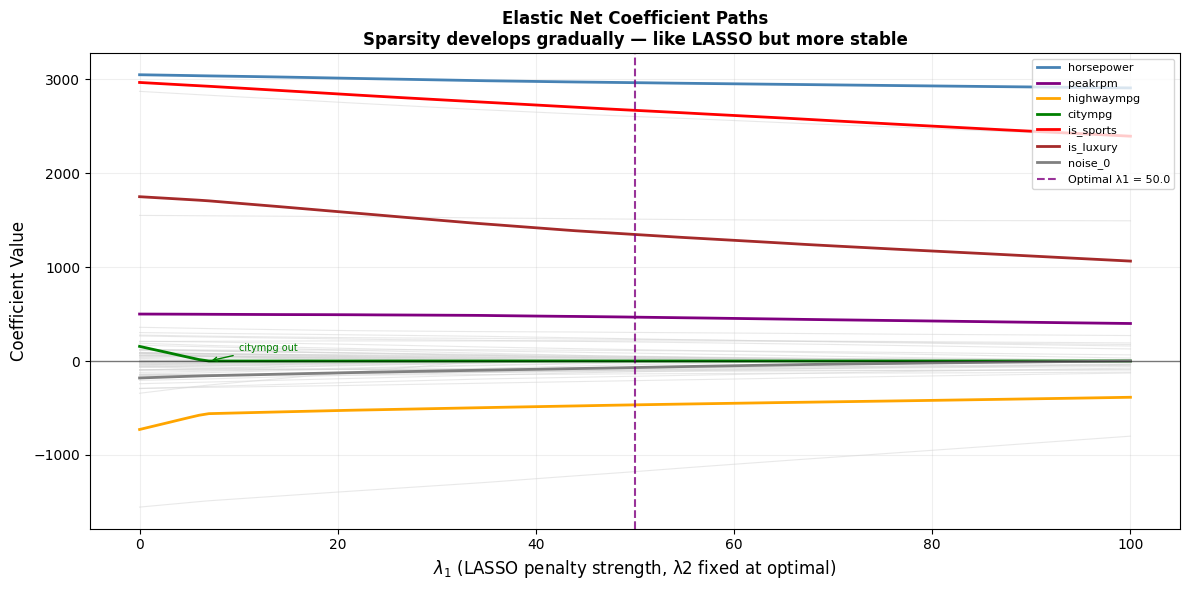

  Elastic Net at Optimal (λ1=50.0, λ2=0.01)
  Features kept    : 44
  Features zeroed  : 24

  Compare with:
  LASSO  — kept 36, zeroed 32
  Ridge  — kept 68, zeroed 0
  Elastic Net — kept 44, zeroed 24

  → Elastic Net sits between LASSO and Ridge:
    more sparse than Ridge, more stable than LASSO 


In [56]:
# ── Plot 2: Elastic Net Coefficient Paths ────────────────────────────────────
# Fix λ2 at optimal value, vary λ1 — show how sparsity develops
# This mirrors the LASSO coefficient path plot from Cell 10

enet_lambdas  = list(range(0, 101))
enet_mse      = []
enet_models   = []

for lam in enet_lambdas:
    l1       = lam
    l2       = optimal_row['lambda2']   # fix Ridge side at optimal
    alpha    = l1 + l2
    l1_ratio = l1 / (l1 + l2)

    enet = ElasticNet(alpha=max(alpha, 1e-6),
                      l1_ratio=l1_ratio,
                      max_iter=10000,
                      random_state=42)
    enet.fit(X_train_scaled, y_train)
    y_pred = enet.predict(X_test_scaled)
    enet_mse.append(mean_squared_error(y_test, y_pred))
    enet_models.append(enet)

enet_coef_paths = np.array([m.coef_ for m in enet_models])

fig, ax = plt.subplots(figsize=(12, 6))

# All features in gray background
for i, feature in enumerate(feature_names):
    if feature not in highlight_features:
        ax.plot(enet_lambdas, enet_coef_paths[:, i],
                color='lightgray', lw=0.8, alpha=0.5)

# Highlighted features
for feature, color in highlight_features.items():
    if feature in feature_names:
        idx   = feature_names.index(feature)
        coefs = enet_coef_paths[:, idx]
        ax.plot(enet_lambdas, coefs,
                color=color, lw=2, label=feature)

        # Mark where kicked out
        zero_crossings = [enet_lambdas[j] for j in range(len(enet_lambdas))
                         if coefs[j] == 0.0]
        if zero_crossings and zero_crossings[0] <= max(enet_lambdas)*0.85:
            ax.annotate(f'{feature} out',
                        xy=(zero_crossings[0], 0),
                        xytext=(zero_crossings[0]+3, 
                                enet_coef_paths[max(0,
                                enet_lambdas.index(zero_crossings[0])-5),
                                idx]),
                        fontsize=7, color=color,
                        arrowprops=dict(arrowstyle='->',
                                        color=color, lw=1))

ax.axvline(optimal_row['lambda1'], color='purple',
           lw=1.5, linestyle='--', alpha=0.8,
           label=f"Optimal λ1 = {optimal_row['lambda1']}")
ax.axhline(0, color='black', lw=1.0, alpha=0.5)

ax.set_xlabel('$\\lambda_1$ (LASSO penalty strength, λ2 fixed at optimal)',
              fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Elastic Net Coefficient Paths\n'
             'Sparsity develops gradually — like LASSO but more stable',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ── Final summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print(f"  Elastic Net at Optimal (λ1={optimal_row['lambda1']},",
      f"λ2={optimal_row['lambda2']})")
print("=" * 60)
n_zeros = np.sum(optimal_enet.coef_ == 0)
n_kept  = np.sum(optimal_enet.coef_ != 0)
print(f"  Features kept    : {n_kept}")
print(f"  Features zeroed  : {n_zeros}")
print(f"\n  Compare with:")
print(f"  LASSO  — kept {np.sum(coef_paths[optimal_idx]!=0)}, "
      f"zeroed {np.sum(coef_paths[optimal_idx]==0)}")
print(f"  Ridge  — kept {np.sum(ridge_coef_paths[ridge_optimal_idx]!=0)}, "
      f"zeroed {np.sum(ridge_coef_paths[ridge_optimal_idx]==0)}")
print(f"  Elastic Net — kept {n_kept}, zeroed {n_zeros}")
print(f"\n  → Elastic Net sits between LASSO and Ridge:")
print(f"    more sparse than Ridge, more stable than LASSO ")
print("=" * 60)

---

## Key Takeaways — Shrinkage Methods

---

### The Core Idea

Standard OLS includes all features with no restrictions.
Shrinkage methods **deliberately accept some bias** in exchange
for **lower variance** — leading to better out-of-sample prediction.

$$\text{Test MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

Shrinkage reduces variance faster than it increases bias —
the net effect is a **lower test MSE**.

---

### The Three Methods

| | OLS | LASSO | Ridge | Elastic Net |
|---|---|---|---|---|
| **Penalty** | None | $\sum\|b_i\|$ | $\sum b_i^2$ | Both |
| **Constraint shape** | None | Diamond ◇ | Circle ○ | Rounded diamond |
| **Zeros out features?** | No | ✓ Yes | ✗ No | Sometimes |
| **Hyperparameters** | None | $\lambda$ | $\lambda$ | $\lambda_1, \lambda_2$ |
| **Closed form?** | ✓ Yes | ✗ No | ✓ Yes | ✗ No |
| **Bias introduced?** | No | Yes | Yes | Yes |
| **Good for causal inference?** | ✓ Yes | ✗ No | ✗ No | ✗ No |
| **Best for** | Causal inference | Sparse prediction | Dense/correlated | Very high dimensional |

---

### The Geometry in One Picture

- **LASSO** penalizes $\sum|b_i|$ → **diamond** constraint
  → has corners on axes → solutions land on corners
  → coefficients go to **exactly zero** → sparsity

- **Ridge** penalizes $\sum b_i^2$ → **circle** constraint
  → smooth boundary, no corners → solutions never land on axes
  → coefficients **never reach zero** → stability

- **Elastic Net** combines both → **rounded diamond**
  → some sparsity + some stability

---

### Why the Penalty Shape Matters

| Penalty | Math property | Shape | Consequence |
|---|---|---|---|
| $\|b\|$ | Kink at zero | Diamond ◇ | Exact zeros → feature selection |
| $b^2$ | Smooth everywhere | Circle ○ | No zeros → all features kept |

---

### Tuning λ — The Universal Workflow

Regardless of which method you use, the tuning workflow
is always the same:
```
1. Standardize continuous features
   (fit scaler on training data only)

2. Split data into train and test sets

3. Loop over a grid of λ values

4. For each λ:
   a. Fit model on training set
   b. Predict on test set
   c. Record test MSE

5. Pick λ with lowest test MSE

6. Check full U-shape is visible
   (if optimal λ is at edge → extend range)
```

---

### When To Use Which Method

| Situation | Method |
|---|---|
| Causal inference | OLS (think carefully about controls) |
| Many irrelevant features | LASSO |
| Highly correlated features | Ridge |
| Need interpretability | LASSO |
| Very high dimensional ($k$ very large) | Elastic Net |
| Unsure | Try all three, pick lowest test MSE |

---

### Connections to What We Already Know

| New Concept | Connection to Earlier Material |
|---|---|
| $\lambda$ hyperparameter | Same role as polynomial degree — tune via test MSE |
| U-shaped MSE curve | Same bias-variance tradeoff from polynomial regression |
| Standardization | Same train/test discipline — fit on training only |
| LASSO kicks out features | Same intuition as OVB — correlated features inflate variance |
| Ridge keeps correlated features | Same issue as imperfect collinearity from Recitation 6 |

---

### One Line Summary

> **LASSO** selects features. **Ridge** stabilizes them.
> **Elastic Net** does both. All three beat OLS
> when prediction — not causation — is the goal.